<a href="https://colab.research.google.com/github/anapbatista/recinfo/blob/main/trabalho_pratico_recinfo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático 1 - Recuperação de Informação (SCC0282)

**Integrantes do grupo:** Ana Paula de Abreu Batista - 12688424

**Dataset:** Cranfield (via biblioteca `ir_datasets`)

Este notebook implementa e avalia dois modelos clássicos de Recuperação de Informação — o **Modelo Vetorial (TF-IDF + Similaridade do Cosseno)** e o **Modelo Probabilístico BM25** — comparando quatro estratégias de pré-processamento, realizando avaliação quantitativa (Precision@10, Recall@10, MAP, F1@10, MRR e NDCG@10), análise qualitativa por consulta, variação de parâmetros do BM25 e análise de erros, conforme os requisitos do enunciado. Todos os resultados (métricas por consulta e agregadas, e os gráficos) são salvos na pasta `resultados/`.


## Configuração do Dataset Cranfield
Instalando as bibliotecas usadas no notebook: `ir-datasets` (acesso estruturado ao Cranfield), `nltk` (stopwords e stemming), `scikit-learn` (TF-IDF e cosseno), `pandas`, `numpy` e `matplotlib`. Em ambiente local, o equivalente é `pip install -r requirements.txt`.

In [1]:
%pip install -q --disable-pip-version-check ir-datasets nltk scikit-learn pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
from importlib.metadata import version

# Registro das versões usadas na execução (reprodutibilidade)
print(f"Python {sys.version.split()[0]}")
for pacote in ['ir-datasets', 'nltk', 'scikit-learn', 'pandas', 'numpy', 'matplotlib']:
    print(f"{pacote}: {version(pacote)}")

# Pasta onde todos os CSVs e gráficos gerados pelo notebook são salvos
DIR_RESULTADOS = 'resultados'
os.makedirs(DIR_RESULTADOS, exist_ok=True)

Python 3.13.13
ir-datasets: 0.6.3
nltk: 3.10.3
scikit-learn: 1.9.1
pandas: 3.0.6
numpy: 2.5.3
matplotlib: 3.11.2


Agora, vamos importar a biblioteca e carregar o dataset Cranfield, explorando a estrutura de documentos, queries e qrels (relevâncias).

In [3]:
import ir_datasets
import pandas as pd
import numpy as np

# Carrega o dataset Cranfield
dataset = ir_datasets.load("cranfield")

# Converte os documentos para um DataFrame do Pandas
docs_df = pd.DataFrame([{ 'doc_id': doc.doc_id, 'title': doc.title, 'text': doc.text, 'author': doc.author, 'bib': doc.bib } for doc in dataset.docs_iter()])

# Converte as queries (consultas) para um DataFrame
queries_df = pd.DataFrame([{ 'query_id': query.query_id, 'text': query.text } for query in dataset.queries_iter()])

# Converte os qrels (julgamentos de relevância) para um DataFrame
qrels_df = pd.DataFrame([{ 'query_id': qrel.query_id, 'doc_id': qrel.doc_id, 'relevance': qrel.relevance, 'iteration': qrel.iteration } for qrel in dataset.qrels_iter()])

# Garante que os ids sejam tratados como string em todo o notebook (evita bugs de comparação int/str)
docs_df['doc_id'] = docs_df['doc_id'].astype(str)
queries_df['query_id'] = queries_df['query_id'].astype(str)
qrels_df['query_id'] = qrels_df['query_id'].astype(str)
qrels_df['doc_id'] = qrels_df['doc_id'].astype(str)

# Exibe informações gerais e as primeiras linhas de cada conjunto
print(f"Total de Documentos: {len(docs_df)}")
print(f"Total de Queries: {len(queries_df)}")
print(f"Total de Julgamentos de Relevância (Qrels): {len(qrels_df)}")


Total de Documentos: 1400
Total de Queries: 225
Total de Julgamentos de Relevância (Qrels): 1837


In [4]:
print("--- Amostra de Documentos ---")
display(docs_df.head(2))

print("\n--- Amostra de Queries ---")
display(queries_df.head(2))

print("\n--- Amostra de Qrels ---")
display(qrels_df.head(2))

print("\n--- Distribuição dos graus de relevância nos Qrels ---")
display(qrels_df['relevance'].value_counts().sort_index())


--- Amostra de Documentos ---


,doc_id,title,text,author,bib
0,1,experimental investigation of the aerodynamics...,experimental investigation of the aerodynamics...,"brenckman,m.","j. ae. scs. 25, 1958, 324."
1,2,simple shear flow past a flat plate in an inco...,simple shear flow past a flat plate in an inco...,ting-yili,"department of aeronautical engineering, rensse..."



--- Amostra de Queries ---


,query_id,text
0,1,what similarity laws must be obeyed when const...
1,2,what are the structural and aeroelastic proble...



--- Amostra de Qrels ---


,query_id,doc_id,relevance,iteration
0,1,184,2,0
1,1,29,2,0



--- Distribuição dos graus de relevância nos Qrels ---


relevance
-1    225
 1    128
 2    387
 3    734
 4    363
Name: count, dtype: int64

## Etapa 1: Pré-processamento

Nesta etapa, preparamos o texto dos documentos e das queries. Vamos utilizar a biblioteca `nltk` para obter a lista de stopwords em inglês e o algoritmo de Stemming (Porter Stemmer). Em seguida, criaremos funções para processar os textos seguindo as quatro configurações mínimas exigidas pelo enunciado:
1. **Básico (Raw):** apenas normalização para minúsculas e tokenização (remoção de pontuação), sem remoção de stopwords e sem stemming.
2. **Stopwords:** remoção de palavras vazias (artigos, preposições, etc.), sem stemming.
3. **Stemming:** aplicação de redução ao radical (Porter Stemmer), sem remoção de stopwords.
4. **Stopwords + Stemming:** remoção de stopwords seguida de stemming.

Essas quatro configurações serão aplicadas tanto aos documentos quanto às consultas, e depois serão comparadas quantitativamente na Etapa 4 (não escolhemos a priori qual é "melhor" — isso é resultado do experimento).

In [5]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.stem import PorterStemmer

# Faz o download da lista de stopwords do NLTK (o RegexpTokenizer usa só expressão regular, não precisa do 'punkt')
nltk.download('stopwords', quiet=True)

# Inicializa os componentes
tokenizer = RegexpTokenizer(r'\w+') # Tokeniza removendo pontuação
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text, remove_stopwords=False, use_stemming=False):
    # 1. Normalização para letras minúsculas
    text = str(text).lower()

    # 2. Tokenização
    tokens = tokenizer.tokenize(text)

    # 3. Tratamento de Stopwords
    if remove_stopwords:
        tokens = [token for token in tokens if token not in stop_words]

    # 4. Stemming
    if use_stemming:
        tokens = [stemmer.stem(token) for token in tokens]

    return tokens


Agora, vamos aplicar as 4 variações de pré-processamento aos nossos DataFrames de documentos e consultas. Para os documentos, indexamos a concatenação de título e texto (`full_text`).

**Atenção:** no Cranfield, o campo `text` (campo `.W` do arquivo original) **já começa repetindo o título** do documento (verificado na célula abaixo). Portanto, a concatenação não acrescenta vocabulário novo: o efeito real é **duplicar o título**, aumentando a frequência dos termos do título. Isso funciona como um reforço de peso do título (*title boosting*), já que o título costuma resumir o assunto central do documento. Mantivemos essa decisão porque ela melhora os dois modelos (ver a ablação ao final da Etapa 4).

In [6]:
# Criando as 4 representações para os Documentos (usando título + texto como conteúdo principal)
docs_df['full_text'] = docs_df['title'] + " " + docs_df['text']

docs_df['tokens_basico'] = docs_df['full_text'].apply(lambda x: preprocess(x, remove_stopwords=False, use_stemming=False))
docs_df['tokens_stopwords'] = docs_df['full_text'].apply(lambda x: preprocess(x, remove_stopwords=True, use_stemming=False))
docs_df['tokens_stemming'] = docs_df['full_text'].apply(lambda x: preprocess(x, remove_stopwords=False, use_stemming=True))
docs_df['tokens_both'] = docs_df['full_text'].apply(lambda x: preprocess(x, remove_stopwords=True, use_stemming=True))

# Criando as 4 representações para as Queries
queries_df['tokens_basico'] = queries_df['text'].apply(lambda x: preprocess(x, remove_stopwords=False, use_stemming=False))
queries_df['tokens_stopwords'] = queries_df['text'].apply(lambda x: preprocess(x, remove_stopwords=True, use_stemming=False))
queries_df['tokens_stemming'] = queries_df['text'].apply(lambda x: preprocess(x, remove_stopwords=False, use_stemming=True))
queries_df['tokens_both'] = queries_df['text'].apply(lambda x: preprocess(x, remove_stopwords=True, use_stemming=True))

# Dicionário central que referencia as 4 configurações de pré-processamento usadas no restante do notebook
configuracoes = {
    'basico': 'tokens_basico',
    'stopwords': 'tokens_stopwords',
    'stemming': 'tokens_stemming',
    'both': 'tokens_both'
}

# O campo 'text' do Cranfield já começa com o título: a concatenação apenas duplica o título
docs_com_titulo_no_texto = sum(texto.strip().startswith(titulo.strip())
                               for titulo, texto in zip(docs_df['title'], docs_df['text']))
print(f"Documentos cujo 'text' já começa com o título: {docs_com_titulo_no_texto} de {len(docs_df)}")

print("Pré-processamento concluído com sucesso para documentos e consultas!")


Documentos cujo 'text' já começa com o título: 1398 de 1400
Pré-processamento concluído com sucesso para documentos e consultas!


In [7]:
# Demonstração do resultado do pré-processamento em um exemplo
exemplo_doc = docs_df.iloc[0]
print(f"Texto Original do Doc 1: {exemplo_doc['full_text'][:200]}...")
print(f"\n1. Básico: {exemplo_doc['tokens_basico'][:10]}")
print(f"2. Sem Stopwords: {exemplo_doc['tokens_stopwords'][:10]}")
print(f"3. Com Stemming: {exemplo_doc['tokens_stemming'][:10]}")
print(f"4. Ambos: {exemplo_doc['tokens_both'][:10]}")

print(f"\nTamanho médio dos documentos (em tokens) por configuração:")
for nome, col in configuracoes.items():
    tam_medio = docs_df[col].apply(len).mean()
    print(f"  {nome:10s}: {tam_medio:.2f} tokens/documento em média")


Texto Original do Doc 1: experimental investigation of the aerodynamics of a
wing in a slipstream . experimental investigation of the aerodynamics of a
wing in a slipstream .
  an experimental study of a wing in a propeller s...

1. Básico: ['experimental', 'investigation', 'of', 'the', 'aerodynamics', 'of', 'a', 'wing', 'in', 'a']
2. Sem Stopwords: ['experimental', 'investigation', 'aerodynamics', 'wing', 'slipstream', 'experimental', 'investigation', 'aerodynamics', 'wing', 'slipstream']
3. Com Stemming: ['experiment', 'investig', 'of', 'the', 'aerodynam', 'of', 'a', 'wing', 'in', 'a']
4. Ambos: ['experiment', 'investig', 'aerodynam', 'wing', 'slipstream', 'experiment', 'investig', 'aerodynam', 'wing', 'slipstream']

Tamanho médio dos documentos (em tokens) por configuração:
  basico    : 173.72 tokens/documento em média
  stopwords : 102.94 tokens/documento em média
  stemming  : 173.72 tokens/documento em média
  both      : 102.94 tokens/documento em média


## Etapa 2: Modelo Vetorial (TF-IDF e Similaridade do Cosseno)

**Representação:** cada documento e cada consulta são representados como um vetor em um espaço vetorial de $|V|$ dimensões, onde $|V|$ é o tamanho do vocabulário (número de termos únicos após o pré-processamento). A coordenada $i$ do vetor de um documento $d$ é o peso TF-IDF do termo $i$ nesse documento:

$$w_{i,d} = tf_{i,d} \times idf_i, \qquad idf_i = \ln\left(\frac{1 + N}{1 + df_i}\right) + 1$$

onde $tf_{i,d}$ é a frequência bruta do termo $i$ no documento $d$, $N$ é o número total de documentos e $df_i$ é o número de documentos em que o termo $i$ ocorre. Essa é a fórmula padrão do `TfidfVectorizer` do scikit-learn, que deixamos explícita nos parâmetros:
- `smooth_idf=True`: o "+1" dentro do logaritmo equivale a somar um documento fictício que contém todos os termos (evita divisão por zero);
- `sublinear_tf=False`: o $tf$ é a contagem bruta, sem logaritmo — o peso cresce linearmente com a repetição;
- `norm='l2'`: cada vetor (documento ou consulta) é dividido pela sua norma L2.

O "+1" fora do logaritmo faz com que até um termo presente em todos os documentos tenha $idf = 1$, e não zero — por isso stopwords ainda pesam no Modelo Vetorial quando não são removidas.

A consulta é projetada no **mesmo espaço vetorial** dos documentos (mesmo vocabulário, mesmo IDF aprendido no corpus), usando `vectorizer.transform()` em vez de `fit_transform()` — isso é essencial: se ajustássemos um vocabulário novo para a consulta, os vetores não seriam comparáveis. Termos da consulta fora do vocabulário do corpus são ignorados.

**Cálculo do score:** o score de similaridade entre a consulta $q$ e um documento $d$ é o cosseno do ângulo entre os dois vetores:

$$\text{sim}(q,d) = \cos(\theta) = \frac{\vec{q}\cdot\vec{d}}{\lVert \vec{q}\rVert \lVert \vec{d}\rVert} = \sum_{t} \hat{q}_t \, \hat{d}_t$$

onde $\hat{q}$ e $\hat{d}$ são os vetores já normalizados. Quanto mais próximo de 1, mais similar (em direção) é o vetor do documento ao vetor da consulta; termos ausentes em um dos dois não contribuem, e a normalização faz com que documentos longos não sejam favorecidos apenas por conter mais palavras. O ranking final ordena os documentos por esse score em ordem decrescente.

Vamos construir um `TfidfVectorizer` e calcular a matriz TF-IDF **para cada uma das 4 configurações de pré-processamento**, permitindo comparar o efeito do pré-processamento também no Modelo Vetorial.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Função auxiliar: como os tokens já foram pré-processados manualmente (Etapa 1),
# usamos um tokenizer/preprocessor "identidade" para impedir que o TfidfVectorizer
# reprocesse o texto (ele receberia listas de tokens já prontas).
def identity_tokenizer(text_list):
    return text_list

# Dicionário para guardar os vetorizadores e as matrizes TF-IDF de cada configuração
modelos_vetoriais = {}

for nome_config, col_tokens in configuracoes.items():
    vectorizer = TfidfVectorizer(
        tokenizer=identity_tokenizer,
        lowercase=False,
        preprocessor=identity_tokenizer,
        token_pattern=None,
        smooth_idf=True,     # idf = ln((1 + N) / (1 + df)) + 1  (padrão do scikit-learn)
        sublinear_tf=False,  # tf bruto (contagem), sem logaritmo
        norm='l2'            # vetores normalizados: o cosseno vira um produto escalar
    )

    # Ajusta o vocabulário e transforma os documentos em vetores TF-IDF
    tfidf_matrix = vectorizer.fit_transform(docs_df[col_tokens])

    modelos_vetoriais[nome_config] = {
        'vectorizer': vectorizer,
        'tfidf_matrix': tfidf_matrix
    }

    print(f"Configuração '{nome_config}': {tfidf_matrix.shape[1]} termos únicos no vocabulário.")


Configuração 'basico': 7471 termos únicos no vocabulário.
Configuração 'stopwords': 7352 termos únicos no vocabulário.
Configuração 'stemming': 4820 termos únicos no vocabulário.
Configuração 'both': 4709 termos únicos no vocabulário.


Com os modelos TF-IDF criados, vamos implementar a função de recuperação: dada uma consulta (já tokenizada) e uma configuração de pré-processamento, a função projeta a consulta no espaço vetorial daquela configuração (`vectorizer.transform`), calcula a similaridade do cosseno contra todos os documentos e retorna o ranking ordenado por score decrescente.

In [9]:
def buscar_modelo_vetorial(query_tokens, nome_config, top_n=None):
    # Recupera o vetorizador e a matriz de documentos adequados
    vectorizer = modelos_vetoriais[nome_config]['vectorizer']
    tfidf_matrix = modelos_vetoriais[nome_config]['tfidf_matrix']

    # Transforma a query usando o MESMO vetorizador (vocabulário e IDF) do corpus de documentos
    query_vector = vectorizer.transform([query_tokens])

    # Calcula a similaridade do cosseno entre o vetor da query e todos os documentos
    scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Cria uma lista de tuplas (doc_id, score), mantendo apenas documentos com alguma correspondência
    ranking = []
    for idx, score in enumerate(scores):
        if score > 0.0:
            doc_id = docs_df.iloc[idx]['doc_id']
            ranking.append((doc_id, float(score)))

    # Ordena o ranking pelo score de forma decrescente
    ranking = sorted(ranking, key=lambda x: x[1], reverse=True)

    if top_n:
        return ranking[:top_n]
    return ranking


In [10]:
# Demonstração: Buscando com a primeira query usando a configuração 'both' (Stopwords + Stemming)
exemplo_query = queries_df.iloc[0]
tokens_exemplo = exemplo_query['tokens_both']

print(f"Query Original: {exemplo_query['text']}")
print(f"Tokens da Query: {tokens_exemplo}")

resultados = buscar_modelo_vetorial(tokens_exemplo, 'both', top_n=5)
print("\n--- Top 5 Documentos Recuperados ---")
for ranking_pos, (doc_id, score) in enumerate(resultados, 1):
    titulo_doc = docs_df[docs_df['doc_id'] == doc_id]['title'].values[0]
    print(f"{ranking_pos}. Doc ID {doc_id} - Score: {score:.4f} | Título: {titulo_doc[:80]}...")


Query Original: what similarity laws must be obeyed when constructing aeroelastic models
of heated high speed aircraft .
Tokens da Query: ['similar', 'law', 'must', 'obey', 'construct', 'aeroelast', 'model', 'heat', 'high', 'speed', 'aircraft']

--- Top 5 Documentos Recuperados ---


1. Doc ID 51 - Score: 0.3108 | Título: theory of aircraft structural models subjected to aerodynamic
heating and extern...


2. Doc ID 184 - Score: 0.2700 | Título: scale models for thermo-aeroelastic research ....
3. Doc ID 12 - Score: 0.2425 | Título: some structural and aerelastic considerations of high
speed flight ....
4. Doc ID 746 - Score: 0.2384 | Título: aeroelastic problems in connection with high speed
flight ....
5. Doc ID 359 - Score: 0.2203 | Título: note on the hypersonic similarity law for an unyawed
cone ....


## Etapa 3: Modelo Probabilístico (BM25)

Implementamos o BM25 **explicitamente** (sem usar uma biblioteca que esconda o cálculo do score), seguindo a formulação clássica de Robertson & Zaragoza. O score de um documento $d$ para uma consulta $q$ é:

$$\text{score}(q,d) = \sum_{t \in q} IDF(t) \cdot \frac{f_{t,d}\,(k_1+1)}{f_{t,d} + k_1\left(1 - b + b\cdot\frac{|d|}{avgdl}\right)}$$

onde:
- $f_{t,d}$ é a frequência do termo $t$ no documento $d$;
- $|d|$ é o comprimento (em tokens) do documento $d$ e $avgdl$ é o comprimento médio dos documentos do corpus;
- $k_1$ controla a **saturação da frequência de termos** — quanto maior $k_1$, mais repetições de um termo continuam aumentando o score (com $k_1 \to 0$ o modelo se torna quase binário: só importa se o termo aparece ou não);
- $b \in [0,1]$ controla a **normalização pelo comprimento do documento** — com $b=0$ não há penalização por tamanho; com $b=1$ a penalização é total;
- $IDF(t) = \log\left(\dfrac{N - df_t + 0.5}{df_t + 0.5} + 1\right)$ é o IDF probabilístico do BM25 (o "+1" evita valores negativos para termos muito frequentes, uma variante comum, tipo Lucene).
- Termos repetidos na **consulta** são somados a cada ocorrência (o laço percorre `query_tokens` com repetições): um termo que aparece duas vezes na consulta contribui em dobro. A saturação controlada por $k_1$ vale apenas para a frequência do termo **no documento** — não implementamos o parâmetro $k_3$, que saturaria a frequência na consulta.

A classe abaixo pré-calcula, para cada configuração de pré-processamento, as frequências de termos por documento, os comprimentos dos documentos, o `avgdl` e o IDF de cada termo do vocabulário — e depois calcula o score sob demanda para qualquer par (consulta, documento), permitindo variar $k_1$ e $b$ livremente na Etapa 6.

In [11]:
import math
from collections import Counter

class BM25Modelo:
    def __init__(self, corpus_tokens, k1=1.5, b=0.75):
        self.k1 = k1
        self.b = b
        self.corpus_size = len(corpus_tokens)
        self.doc_lengths = [len(doc) for doc in corpus_tokens]
        self.avgdl = sum(self.doc_lengths) / self.corpus_size

        # Frequência de termos por documento e contagem de documentos que possuem cada termo
        self.doc_term_freqs = [Counter(doc) for doc in corpus_tokens]
        self.doc_freqs = {}

        for doc in corpus_tokens:
            for term in set(doc):
                self.doc_freqs[term] = self.doc_freqs.get(term, 0) + 1

        # Pré-calcula o IDF (fórmula probabilística do BM25 / Okapi, variante Lucene com +1)
        self.idf = {}
        for term, df in self.doc_freqs.items():
            self.idf[term] = math.log((self.corpus_size - df + 0.5) / (df + 0.5) + 1.0)

    def obter_score(self, query_tokens, doc_index):
        score = 0.0
        doc_len = self.doc_lengths[doc_index]
        term_freqs = self.doc_term_freqs[doc_index]

        for term in query_tokens:
            if term not in self.doc_freqs:
                continue  # termo fora do vocabulário do corpus: não contribui (IDF indefinido)

            tf = term_freqs[term]
            idf_val = self.idf[term]

            # Numerador: saturação de frequência do termo (limitada por k1)
            numerador = tf * (self.k1 + 1)
            # Denominador: saturação + normalização pelo comprimento do documento (controlada por b)
            denominador = tf + self.k1 * (1 - self.b + self.b * (doc_len / self.avgdl)) + 1e-9
            # 1e-9: constante infinitesimal apenas para evitar divisão por zero quando k1=0 e tf=0
            score += idf_val * (numerador / denominador)

        return score

    def buscar(self, query_tokens, docs_df, top_n=None):
        ranking = []
        for idx in range(self.corpus_size):
            score = self.obter_score(query_tokens, idx)
            if score > 0.0:
                doc_id = docs_df.iloc[idx]['doc_id']
                ranking.append((doc_id, score))

        ranking = sorted(ranking, key=lambda x: x[1], reverse=True)

        if top_n:
            return ranking[:top_n]
        return ranking


Agora, vamos instanciar o modelo BM25 (com os parâmetros padrão $k_1=1.5$, $b=0.75$, valores comumente recomendados na literatura) para cada uma das 4 configurações de pré-processamento que criamos. A variação sistemática de $k_1$ e $b$ é feita separadamente na Etapa 6.

In [12]:
modelos_bm25 = {}

# Criando instâncias do BM25 para cada uma das configurações de tokens
for nome_config, col_tokens in configuracoes.items():
    modelos_bm25[nome_config] = BM25Modelo(docs_df[col_tokens].tolist(), k1=1.5, b=0.75)
    print(f"Modelo BM25 inicializado para a configuração '{nome_config}'.")


Modelo BM25 inicializado para a configuração 'basico'.
Modelo BM25 inicializado para a configuração 'stopwords'.


Modelo BM25 inicializado para a configuração 'stemming'.
Modelo BM25 inicializado para a configuração 'both'.


In [13]:
# Demonstração: Buscando com a primeira query no BM25 usando a configuração 'both'
tokens_exemplo = queries_df.iloc[0]['tokens_both']

resultados_bm25 = modelos_bm25['both'].buscar(tokens_exemplo, docs_df, top_n=5)
print("\n--- Top 5 Documentos Recuperados pelo BM25 ---")
for ranking_pos, (doc_id, score) in enumerate(resultados_bm25, 1):
    titulo_doc = docs_df[docs_df['doc_id'] == doc_id]['title'].values[0]
    print(f"{ranking_pos}. Doc ID {doc_id} - Score BM25: {score:.4f} | Título: {titulo_doc[:80]}...")



--- Top 5 Documentos Recuperados pelo BM25 ---
1. Doc ID 51 - Score BM25: 23.4460 | Título: theory of aircraft structural models subjected to aerodynamic
heating and extern...
2. Doc ID 486 - Score BM25: 22.1423 | Título: similarity laws for aerothermoelastic testing ....
3. Doc ID 12 - Score BM25: 19.6756 | Título: some structural and aerelastic considerations of high
speed flight ....
4. Doc ID 184 - Score BM25: 19.0324 | Título: scale models for thermo-aeroelastic research ....
5. Doc ID 878 - Score BM25: 17.2506 | Título: experimental model techniques and equipment for flutter
investigations ....


## Etapa 4: Avaliação Quantitativa

Nesta etapa implementamos as métricas de avaliação e calculamos o desempenho dos dois modelos (Vetorial e BM25) para as quatro variações de pré-processamento, **por consulta e agregado** (média sobre todas as consultas), conforme exigido.

### Definição de relevância binária
Seguindo o enunciado: consideramos **relevante** todo documento com grau de relevância $\geq 1$ nos qrels. Julgamentos com valor `-1` e documentos não julgados (ausentes dos qrels) são tratados como **não relevantes**. Essa definição é usada em Precision@10, Recall@10, MAP, F1@10 e MRR (todas métricas binárias).

### Relevância graduada (para NDCG)
Para o NDCG@10 usamos os graus positivos dos qrels como relevância graduada. **Observação importante sobre a escala do Cranfield:** nesta coleção o grau `1` significa a *resposta mais relevante* e o grau `4` significa *relevância mínima* (ou seja, quanto **menor** o número, **maior** a relevância) — o oposto do que normalmente se assume em outras coleções (onde grau maior = mais relevante).

Essa é a definição de Cleverdon registrada no arquivo `cranqrel.readme` da coleção original (`cran.tar.gz`, o mesmo arquivo baixado pelo `ir_datasets`):

> 1. References which are a complete answer to the question.
> 2. References of a high degree of relevance, the lack of which either would have made the research impracticable or would have resulted in a considerable amount of extra work.
> 3. References which were useful, either as general background to the work or as suggesting methods of tackling certain aspects of the work.
> 4. References of minimum interest, for example, those that have been included from an historical viewpoint.

A página de documentação do `ir_datasets` lista os graus na ordem inversa (4 = resposta completa), mas a biblioteca repassa os valores do arquivo original sem transformá-los — por isso seguimos o readme. Antes de calcular o NDCG, invertemos a escala para um "peso de ganho" $g$ consistente com a definição usual de DCG (ganho maior ⇒ documento mais relevante):

$$g(\text{grau}) = \begin{cases} 5 - \text{grau}, & \text{se grau} \in \{1,2,3,4\} \\ 0, & \text{caso contrário (não relevante ou não julgado)}\end{cases}$$

Assim, grau 1 (melhor resposta) recebe peso 4, e grau 4 (relevância mínima) recebe peso 1. Sem essa correção, o NDCG penalizaria erroneamente os documentos mais relevantes da coleção.

### Métricas calculadas
- **Precision@10**: fração de documentos relevantes entre os 10 primeiros retornados.
- **Recall@10**: fração dos documentos relevantes da consulta que aparecem entre os 10 primeiros.
- **F1@10**: média harmônica entre Precision@10 e Recall@10.
- **MAP (Mean Average Precision)**: média da Average Precision (AP) sobre todas as consultas; a AP de uma consulta é a média das precisões calculadas em cada posição do ranking completo em que um documento relevante foi recuperado.
- **MRR (Mean Reciprocal Rank)**: média do inverso da posição do primeiro documento relevante recuperado.
- **NDCG@10**: Normalized Discounted Cumulative Gain nos 10 primeiros, usando a relevância graduada (com a inversão de escala descrita acima).

In [14]:
def obter_relevantes_por_query(qrels_df):
    """Para cada query, retorna o conjunto de doc_ids relevantes (grau >= 1) e o dicionário
    de graus de relevância originais (>=1) usado depois para o NDCG."""
    relevantes = {}
    graus = {}
    for _, row in qrels_df.iterrows():
        q_id = str(row['query_id'])
        doc_id = str(row['doc_id'])
        rel = int(row['relevance'])
        if rel >= 1:
            relevantes.setdefault(q_id, set()).add(doc_id)
            graus.setdefault(q_id, {})[doc_id] = rel
    return relevantes, graus

relevantes_reais, graus_reais = obter_relevantes_por_query(qrels_df)


def peso_ganho(grau):
    """Converte o grau de relevância do Cranfield (1=melhor ... 4=pior) em peso de ganho
    para o DCG (quanto maior o peso, mais relevante). Ver explicação na célula acima."""
    if grau is None or grau < 1:
        return 0
    return 5 - grau


def dcg_at_k(ganhos, k):
    dcg = 0.0
    for i, g in enumerate(ganhos[:k]):
        dcg += g / math.log2(i + 2)  # i+2 pois a posição 1 (i=0) usa log2(2)=1
    return dcg


def ndcg_at_k(ranking, graus_query, k=10):
    if not graus_query:
        return 0.0
    ganhos_obtidos = [peso_ganho(graus_query.get(str(doc_id))) for doc_id, _ in ranking[:k]]
    dcg = dcg_at_k(ganhos_obtidos, k)

    ganhos_ideais = sorted([peso_ganho(g) for g in graus_query.values()], reverse=True)
    idcg = dcg_at_k(ganhos_ideais, k)

    return dcg / idcg if idcg > 0 else 0.0


def reciprocal_rank(ranking, rel_docs):
    for idx, (doc_id, _) in enumerate(ranking):
        if str(doc_id) in rel_docs:
            return 1.0 / (idx + 1)
    return 0.0


def calcular_metricas_completas(ranking, rel_docs, graus_query=None, k=10):
    """Calcula Precision@k, Recall@k, F1@k, Average Precision, Reciprocal Rank e NDCG@k
    para um único ranking (lista ordenada de (doc_id, score)) de uma consulta."""
    if not rel_docs:
        return dict(precision=0.0, recall=0.0, f1=0.0, ap=0.0, rr=0.0, ndcg=0.0)

    top_k = ranking[:k]
    recuperados_k = [str(doc_id) for doc_id, _ in top_k]

    # Precision@k e Recall@k
    relevantes_recuperados_k = [d for d in recuperados_k if d in rel_docs]
    precision_at_k = len(relevantes_recuperados_k) / k
    recall_at_k = len(relevantes_recuperados_k) / len(rel_docs)

    # F1@k
    if (precision_at_k + recall_at_k) > 0:
        f1_at_k = 2 * precision_at_k * recall_at_k / (precision_at_k + recall_at_k)
    else:
        f1_at_k = 0.0

    # Average Precision (considerando o ranking completo retornado, não só o top-k)
    ap_soma = 0.0
    relevantes_encontrados = 0
    for idx, (doc_id, _) in enumerate(ranking):
        if str(doc_id) in rel_docs:
            relevantes_encontrados += 1
            ap_soma += relevantes_encontrados / (idx + 1)
    average_precision = ap_soma / len(rel_docs)

    # Reciprocal Rank
    rr = reciprocal_rank(ranking, rel_docs)

    # NDCG@k (relevância graduada)
    ndcg = ndcg_at_k(ranking, graus_query, k) if graus_query else 0.0

    return dict(precision=precision_at_k, recall=recall_at_k, f1=f1_at_k,
                ap=average_precision, rr=rr, ndcg=ndcg)


Agora, vamos rodar **todas** as consultas em **todas** as combinações de modelo (Vetorial, BM25) × pré-processamento (4 configurações), guardando o resultado **por consulta** (`df_resultados_por_query`) e depois o **agregado** (média por configuração/modelo, `df_resultados_agregados`). Ambos são exportados em CSV para compor a entrega de resultados completos.

In [15]:
resultados_por_query = []

for nome_config, col_tokens in configuracoes.items():
    for _, q_row in queries_df.iterrows():
        q_id = str(q_row['query_id'])
        q_tokens = q_row[col_tokens]

        # Ignora consultas sem nenhum julgamento de relevância positivo (não avaliáveis)
        if q_id not in relevantes_reais:
            continue

        rel_docs = relevantes_reais[q_id]
        graus_query = graus_reais.get(q_id, {})

        # --- Modelo Vetorial ---
        ranking_vet = buscar_modelo_vetorial(q_tokens, nome_config)
        m_vet = calcular_metricas_completas(ranking_vet, rel_docs, graus_query, k=10)
        resultados_por_query.append({
            'preprocessamento': nome_config, 'modelo': 'Vetorial (TF-IDF)', 'query_id': q_id,
            'precision_at_10': m_vet['precision'], 'recall_at_10': m_vet['recall'],
            'f1_at_10': m_vet['f1'], 'ap': m_vet['ap'], 'rr': m_vet['rr'], 'ndcg_at_10': m_vet['ndcg']
        })

        # --- BM25 ---
        ranking_bm = modelos_bm25[nome_config].buscar(q_tokens, docs_df)
        m_bm = calcular_metricas_completas(ranking_bm, rel_docs, graus_query, k=10)
        resultados_por_query.append({
            'preprocessamento': nome_config, 'modelo': 'BM25', 'query_id': q_id,
            'precision_at_10': m_bm['precision'], 'recall_at_10': m_bm['recall'],
            'f1_at_10': m_bm['f1'], 'ap': m_bm['ap'], 'rr': m_bm['rr'], 'ndcg_at_10': m_bm['ndcg']
        })

df_resultados_por_query = pd.DataFrame(resultados_por_query)

# Agregação (média por configuração de pré-processamento e modelo) -> métrica MAP, MRR médio, etc.
df_resultados_agregados = (
    df_resultados_por_query
    .groupby(['preprocessamento', 'modelo'])
    .agg(P_at_10=('precision_at_10', 'mean'),
         R_at_10=('recall_at_10', 'mean'),
         F1_at_10=('f1_at_10', 'mean'),
         MAP=('ap', 'mean'),
         MRR=('rr', 'mean'),
         NDCG_at_10=('ndcg_at_10', 'mean'))
    .reset_index()
    .sort_values(by='MAP', ascending=False)
)

# Exporta os resultados completos (por consulta e agregados) para a entrega do projeto
df_resultados_por_query.to_csv(os.path.join(DIR_RESULTADOS, 'resultados_por_consulta.csv'), index=False)
df_resultados_agregados.to_csv(os.path.join(DIR_RESULTADOS, 'resultados_agregados.csv'), index=False)

print(f"Total de linhas em resultados por consulta: {len(df_resultados_por_query)} "
      f"({len(configuracoes)} configs x 2 modelos x {df_resultados_por_query['query_id'].nunique()} queries avaliáveis)")
display(df_resultados_agregados)


Total de linhas em resultados por consulta: 1800 (4 configs x 2 modelos x 225 queries avaliáveis)


,preprocessamento,modelo,P_at_10,R_at_10,F1_at_10,MAP,MRR,NDCG_at_10
2,both,BM25,0.243111,0.407087,0.274711,0.319110,0.550923,0.380157
3,both,Vetorial (TF-IDF),0.243111,0.402349,0.273089,0.307499,0.533780,0.367446
4,stemming,BM25,0.236889,0.396606,0.267738,0.306694,0.535285,0.370654
5,stemming,Vetorial (TF-IDF),0.233778,0.385174,0.261670,0.298175,0.516227,0.354824
6,stopwords,BM25,0.237333,0.401324,0.269976,0.295755,0.529417,0.365582
7,stopwords,Vetorial (TF-IDF),0.223556,0.370429,0.251696,0.283820,0.516178,0.341043
0,basico,BM25,0.229778,0.387564,0.260967,0.282065,0.506332,0.349393
1,basico,Vetorial (TF-IDF),0.227111,0.371130,0.254371,0.277807,0.505288,0.341139


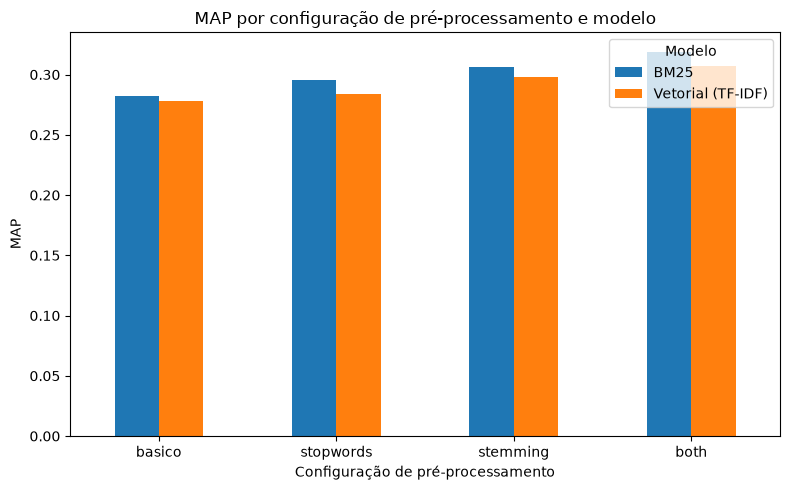

In [16]:
import matplotlib.pyplot as plt

# Gráfico 1: MAP por configuração de pré-processamento, para cada modelo
pivot_map = df_resultados_agregados.pivot(index='preprocessamento', columns='modelo', values='MAP')
pivot_map = pivot_map.reindex(['basico', 'stopwords', 'stemming', 'both'])

ax = pivot_map.plot(kind='bar', figsize=(8, 5), rot=0)
ax.set_title('MAP por configuração de pré-processamento e modelo')
ax.set_xlabel('Configuração de pré-processamento')
ax.set_ylabel('MAP')
ax.legend(title='Modelo')
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'grafico_map_por_config.png'), dpi=150)
plt.show()


Melhor configuração de pré-processamento (maior MAP): 'both'


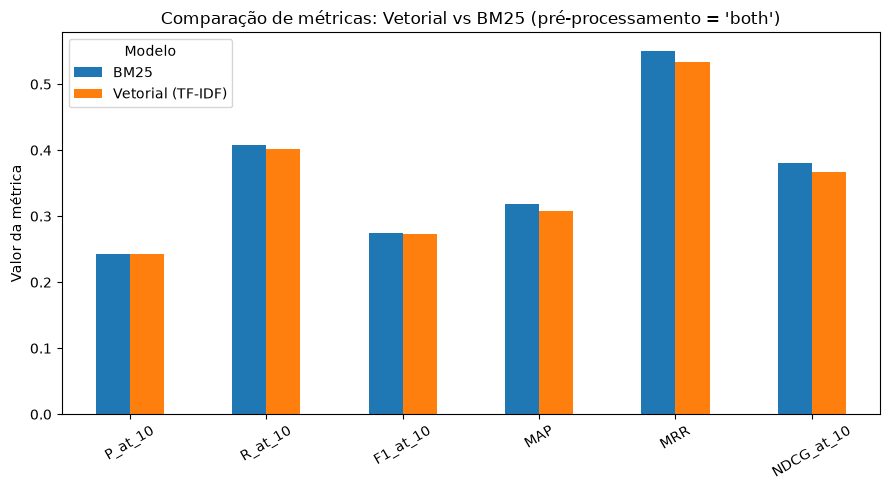

,preprocessamento,modelo,P_at_10,R_at_10,F1_at_10,MAP,MRR,NDCG_at_10
2,both,BM25,0.243111,0.407087,0.274711,0.319110,0.550923,0.380157
3,both,Vetorial (TF-IDF),0.243111,0.402349,0.273089,0.307499,0.533780,0.367446


In [17]:
# Gráfico 2: comparação de todas as métricas para a MELHOR configuração de pré-processamento
melhor_config = df_resultados_agregados.loc[df_resultados_agregados['MAP'].idxmax(), 'preprocessamento']
print(f"Melhor configuração de pré-processamento (maior MAP): '{melhor_config}'")

df_melhor = df_resultados_agregados[df_resultados_agregados['preprocessamento'] == melhor_config]
metricas_cols = ['P_at_10', 'R_at_10', 'F1_at_10', 'MAP', 'MRR', 'NDCG_at_10']

df_plot = df_melhor.set_index('modelo')[metricas_cols]
ax = df_plot.T.plot(kind='bar', figsize=(9, 5), rot=30)
ax.set_title(f"Comparação de métricas: Vetorial vs BM25 (pré-processamento = '{melhor_config}')")
ax.set_ylabel('Valor da métrica')
ax.legend(title='Modelo')
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'grafico_comparacao_metricas.png'), dpi=150)
plt.show()

display(df_melhor)


### Verificação: título duplicado (`title + text`) vs. apenas `text`

Como explicado na Etapa 1, indexar `title + text` equivale a duplicar o título. Para verificar se essa decisão ajuda, comparamos o MAP da configuração `both` indexando apenas o campo `text` (título 1×) contra `full_text` (título 2×), com os mesmos parâmetros ($k_1=1.5$, $b=0.75$ no BM25).

In [18]:
# Ablação: indexa apenas 'text' (título aparece 1x) com a configuração 'both' e compara com 'full_text' (título 2x)
tokens_so_texto = docs_df['text'].apply(lambda x: preprocess(x, remove_stopwords=True, use_stemming=True))

vectorizer_so_texto = TfidfVectorizer(tokenizer=identity_tokenizer, lowercase=False,
                                      preprocessor=identity_tokenizer, token_pattern=None)
modelos_vetoriais['both_so_texto'] = {
    'vectorizer': vectorizer_so_texto,
    'tfidf_matrix': vectorizer_so_texto.fit_transform(tokens_so_texto)
}
bm25_so_texto = BM25Modelo(tokens_so_texto.tolist(), k1=1.5, b=0.75)

ablacao_titulo = []
for _, q_row in queries_df.iterrows():
    q_id = str(q_row['query_id'])
    if q_id not in relevantes_reais:
        continue
    rel_docs, graus_query = relevantes_reais[q_id], graus_reais.get(q_id, {})
    ranking_vet = buscar_modelo_vetorial(q_row['tokens_both'], 'both_so_texto')
    ranking_bm = bm25_so_texto.buscar(q_row['tokens_both'], docs_df)
    ablacao_titulo.append({'query_id': q_id,
                           'ap_vetorial_so_texto': calcular_metricas_completas(ranking_vet, rel_docs, graus_query)['ap'],
                           'ap_bm25_so_texto': calcular_metricas_completas(ranking_bm, rel_docs, graus_query)['ap']})

df_ablacao_titulo = pd.DataFrame(ablacao_titulo)
df_ablacao_titulo.to_csv(os.path.join(DIR_RESULTADOS, 'ablacao_titulo_por_consulta.csv'), index=False)

map_both = df_resultados_agregados[df_resultados_agregados['preprocessamento'] == 'both'].set_index('modelo')['MAP']
display(pd.DataFrame({
    'MAP apenas text (título 1x)': [df_ablacao_titulo['ap_vetorial_so_texto'].mean(), df_ablacao_titulo['ap_bm25_so_texto'].mean()],
    'MAP title + text (título 2x)': [map_both['Vetorial (TF-IDF)'], map_both['BM25']]
}, index=['Vetorial (TF-IDF)', 'BM25']).round(4))

,MAP apenas text (título 1x),MAP title + text (título 2x)
Vetorial (TF-IDF),0.2944,0.3075
BM25,0.3065,0.3191


### Evidências para a análise do pré-processamento

Abaixo, o IDF de algumas stopwords comuns nas consultas (configuração `basico`), exemplos de variantes agrupadas (ou não) pelo Porter Stemmer e a comparação por consulta entre `both` e `basico`.

In [19]:
# IDF de stopwords frequentes nas consultas (configuração 'basico', sem remoção de stopwords)
vec_basico = modelos_vetoriais['basico']['vectorizer']
bm25_basico = modelos_bm25['basico']
display(pd.DataFrame([
    {'termo': t, 'df': bm25_basico.doc_freqs[t],
     'idf_tfidf': round(vec_basico.idf_[vec_basico.vocabulary_[t]], 3), 'idf_bm25': round(bm25_basico.idf[t], 3)}
    for t in ['the', 'of', 'is', 'are', 'can', 'what']
]))
fracao_stop_consultas = queries_df['tokens_basico'].apply(lambda toks: np.mean([t in stop_words for t in toks])).mean()
print(f"Fração média de stopwords nos tokens das consultas: {fracao_stop_consultas:.1%}")

# Variantes agrupadas pelo Porter Stemmer (e variantes que ele NÃO agrupa)
for palavra in ['heated', 'heating', 'stability', 'stabilized', 'theory', 'theoretical', 'sudden', 'suddenly']:
    print(f"  {palavra:12s} -> {stemmer.stem(palavra)}")

# Comparação por consulta: 'both' vs 'basico' (AP)
for modelo in ['BM25', 'Vetorial (TF-IDF)']:
    ap_por_config = df_resultados_por_query[df_resultados_por_query['modelo'] == modelo].pivot(
        index='query_id', columns='preprocessamento', values='ap')
    ganho = ap_por_config['both'] - ap_por_config['basico']
    print(f"{modelo}: 'both' melhor que 'basico' em {(ganho > 1e-9).sum()} consultas, "
          f"pior em {(ganho < -1e-9).sum()}, igual em {(ganho.abs() <= 1e-9).sum()}")

,termo,df,idf_tfidf,idf_bm25
0,the,1391,1.006,0.007
1,of,1394,1.004,0.005
2,is,1151,1.196,0.196
3,are,1028,1.309,0.309
4,can,289,2.575,1.577
5,what,16,5.412,4.442


Fração média de stopwords nos tokens das consultas: 38.6%
  heated       -> heat
  heating      -> heat
  stability    -> stabil
  stabilized   -> stabil
  theory       -> theori
  theoretical  -> theoret
  sudden       -> sudden
  suddenly     -> suddenli
BM25: 'both' melhor que 'basico' em 139 consultas, pior em 75, igual em 11
Vetorial (TF-IDF): 'both' melhor que 'basico' em 137 consultas, pior em 81, igual em 7


### Análise do pré-processamento

- **Stemming é o componente que mais ajuda.** Sozinho, eleva o MAP do BM25 de 0,282 para 0,307 e o do Vetorial de 0,278 para 0,298 (a remoção de stopwords sozinha chega a 0,296 e 0,284). O Porter reduz o vocabulário de 7.471 para 4.820 termos (−35%), agrupando variantes morfológicas (*heated/heating → heat*, *stability/stabilized → stabil*): assim, "heated" na consulta 1 casa com "heating" nos documentos. Ele também tem falhas que reaparecem nas análises seguintes: *theory → theori* e *theoretical → theoret* não são agrupados, nem *sudden → sudden* e *suddenly → suddenli*.
- **Remover stopwords ajuda os dois modelos, mais o BM25.** As consultas do Cranfield são perguntas ("what is...", "can the...", "has anyone..."), e cerca de 39% dos seus tokens são stopwords. Algumas têm IDF alto porque quase não aparecem nos resumos: *what* ocorre em apenas 16 documentos (idf 5,41 no TF-IDF e 4,44 no BM25), então uma consulta que começa com "what" favorece esses 16 documentos sem motivo. Além disso, no TF-IDF o "+1" do IDF mantém *the* e *of* com peso ≈ 1, e essas palavras, muito repetidas, inflam a norma dos vetores dos documentos (as stopwords são ~41% dos tokens dos documentos: 173,7 → 102,9 tokens em média).
- **A combinação `both` é a melhor para os dois modelos** (MAP 0,319 no BM25 e 0,307 no Vetorial, ganhos de 13% e 11% sobre `basico`), mas não em todas as consultas: no BM25, `both` supera `basico` em 139 consultas e perde em 75.
- **Título duplicado:** indexar `title + text` (título 2×) em vez de só `text` (título 1×) eleva o MAP de 0,307 para 0,319 no BM25 e de 0,294 para 0,307 no Vetorial. O título concentra os termos centrais do documento, e dobrar sua frequência funciona como reforço de peso.

## Etapa 5: Comparação Detalhada e Análise por Consulta

Nesta seção comparamos, consulta a consulta, o desempenho (AP e demais métricas) do **Modelo Vetorial** e do **BM25** ($k_1=1.5$, $b=0.75$), ambos com a melhor configuração de pré-processamento da Etapa 4 (`tokens_both`). Primeiro vemos a distribuição da diferença de AP entre os modelos; depois identificamos:
1. Duas consultas em que o **BM25** foi claramente superior;
2. Duas consultas em que o **Modelo Vetorial** foi claramente superior;
3. Duas consultas em que **ambos os modelos** tiveram desempenho insatisfatório.

Para cada caso, exibimos os **5 primeiros documentos retornados** por cada modelo, indicando quais são relevantes segundo os qrels (com o grau original) e qual é o documento-fonte da consulta (julgamento -1, explicado abaixo). Por fim, decompomos os scores por termo para explicar as diferenças.

In [20]:
nome_config_analise = 'both'
col_tokens_analise = 'tokens_both'

analise_queries = []
for _, q_row in queries_df.iterrows():
    q_id = str(q_row['query_id'])
    q_tokens = q_row[col_tokens_analise]

    if q_id not in relevantes_reais:
        continue

    rel_docs = relevantes_reais[q_id]
    graus_query = graus_reais.get(q_id, {})

    ranking_vet = buscar_modelo_vetorial(q_tokens, nome_config_analise)
    m_vet = calcular_metricas_completas(ranking_vet, rel_docs, graus_query, k=10)

    ranking_bm = modelos_bm25[nome_config_analise].buscar(q_tokens, docs_df)
    m_bm = calcular_metricas_completas(ranking_bm, rel_docs, graus_query, k=10)

    analise_queries.append({
        'query_id': q_id,
        'texto_original': q_row['text'].strip(),
        'AP_Vetorial': m_vet['ap'], 'P10_Vetorial': m_vet['precision'], 'NDCG_Vetorial': m_vet['ndcg'],
        'AP_BM25': m_bm['ap'], 'P10_BM25': m_bm['precision'], 'NDCG_BM25': m_bm['ndcg'],
        'Diferenca_BM25_menos_Vetorial': m_bm['ap'] - m_vet['ap'],
        'Media_AP': (m_bm['ap'] + m_vet['ap']) / 2.0
    })

df_analise_queries = pd.DataFrame(analise_queries)
df_analise_queries.to_csv(os.path.join(DIR_RESULTADOS, 'analise_por_consulta_ambos_modelos.csv'), index=False)
diferenca_ap = df_analise_queries['Diferenca_BM25_menos_Vetorial']
print(f"AP maior no BM25: {(diferenca_ap > 1e-9).sum()} consultas | AP maior no Vetorial: {(diferenca_ap < -1e-9).sum()} | "
      f"empates: {(diferenca_ap.abs() <= 1e-9).sum()} | consultas com |ΔAP| > 0.1: {(diferenca_ap.abs() > 0.1).sum()}")
display(df_analise_queries.sort_values(by='Diferenca_BM25_menos_Vetorial', ascending=False).head(5))


AP maior no BM25: 121 consultas | AP maior no Vetorial: 96 | empates: 8 | consultas com |ΔAP| > 0.1: 52


,query_id,texto_original,AP_Vetorial,P10_Vetorial,NDCG_Vetorial,AP_BM25,P10_BM25,NDCG_BM25,Diferenca_BM25_menos_Vetorial,Media_AP
35,36,has anyone investigated relaxation effects on ...,0.064476,0.1,0.148041,0.502375,0.1,0.469279,0.437899,0.283426
172,173,references on lyapunov's method on the stabili...,0.583333,0.2,0.693426,1.000000,0.2,1.000000,0.416667,0.791667
14,15,material properties of photoelastic materials .,0.666667,0.2,0.650878,1.000000,0.2,0.859719,0.333333,0.833333
204,205,has anyone investigated theoretically whether ...,0.500000,0.2,0.650921,0.833333,0.2,0.919721,0.333333,0.666667
166,167,exact solution methods for calculating the abl...,0.088346,0.0,0.000000,0.416667,0.2,0.554066,0.328321,0.252506


### Distribuição da diferença de AP entre os modelos

Cada barra é uma consulta; valores positivos indicam AP maior no BM25 e negativos, AP maior no Modelo Vetorial. As consultas analisadas em detalhe abaixo estão nas pontas.

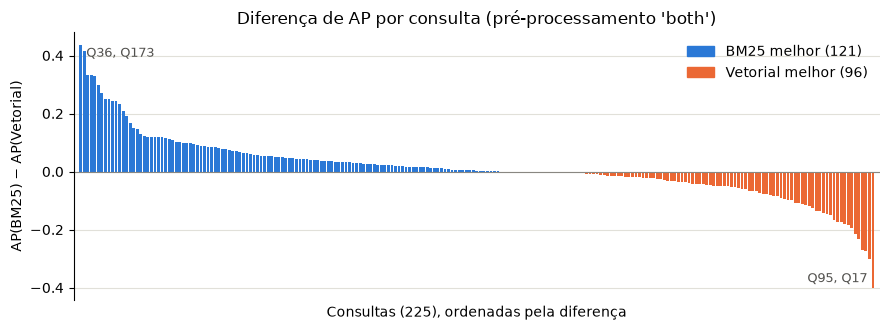

In [21]:
from matplotlib.patches import Patch

# Gráfico 3: diferença de AP (BM25 - Vetorial) por consulta, ordenada
dif_ordenada = df_analise_queries.sort_values('Diferenca_BM25_menos_Vetorial', ascending=False).reset_index(drop=True)
valores = dif_ordenada['Diferenca_BM25_menos_Vetorial']
cor_bm25, cor_vetorial = '#2a78d6', '#eb6834'

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(range(len(valores)), valores, width=0.8, color=np.where(valores > 0, cor_bm25, cor_vetorial))
ax.axhline(0, color='#898781', linewidth=0.8)
ax.annotate('Q36, Q173', (0, valores.iloc[0]), xytext=(4, -2), textcoords='offset points',
            ha='left', va='top', fontsize=9, color='#52514e')
ax.annotate('Q95, Q17', (len(valores) - 1, valores.iloc[-1]), xytext=(-4, 2), textcoords='offset points',
            ha='right', va='bottom', fontsize=9, color='#52514e')
ax.set_xlim(-2, len(valores) + 1)
ax.set_xticks([])
ax.set_xlabel(f'Consultas ({len(valores)}), ordenadas pela diferença')
ax.set_ylabel('AP(BM25) − AP(Vetorial)')
ax.set_title("Diferença de AP por consulta (pré-processamento 'both')")
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ['top', 'right', 'bottom']:
    ax.spines[lado].set_visible(False)
ax.legend(handles=[Patch(color=cor_bm25, label=f'BM25 melhor ({(valores > 1e-9).sum()})'),
                   Patch(color=cor_vetorial, label=f'Vetorial melhor ({(valores < -1e-9).sum()})')],
          frameon=False, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'grafico_diferenca_ap_por_consulta.png'), dpi=150)
plt.show()

### Os documentos com julgamento -1 (documento-fonte da consulta)

Os qrels do Cranfield têm 225 julgamentos -1 — exatamente um por consulta. O `cranqrel.readme` original não define o valor -1 (e diz que os qrels não incluem o grau 5, *no interest*). O padrão é consistente com a metodologia do Cranfield II, em que autores de artigos-base formularam perguntas sobre o problema tratado no próprio artigo e depois julgaram as referências: o documento -1 é, com toda probabilidade, **o artigo a partir do qual a pergunta foi formulada**. Por exemplo, o -1 da consulta 1 (*what similarity laws must be obeyed when constructing aeroelastic models of heated high speed aircraft*) é o doc 486, *similarity laws for aerothermoelastic testing*; e consultas consecutivas compartilham o mesmo -1 (as consultas 1 e 2 têm o doc 486; as consultas 4 e 5, o doc 488), como perguntas suplementares de um mesmo autor.

Seguindo a especificação, esses documentos são tratados como **não relevantes**. Mas, como são lexicalmente muito próximos da consulta, aparecem com frequência no topo dos rankings e contam como erro — o que precisa ser levado em conta na análise:

In [22]:
# Mapeia cada consulta ao seu documento com julgamento -1 (documento-fonte)
julgamentos_negativos = qrels_df[qrels_df['relevance'] == -1]
doc_fonte = dict(zip(julgamentos_negativos['query_id'], julgamentos_negativos['doc_id']))
print(f"Julgamentos -1: {len(julgamentos_negativos)} | consultas com exatamente um -1: "
      f"{(julgamentos_negativos.groupby('query_id').size() == 1).sum()} de {len(queries_df)}")

# Posição do documento-fonte no ranking de cada modelo (configuração 'both', BM25 com k1=1.5, b=0.75)
posicoes_fonte = []
for _, q_row in queries_df.iterrows():
    q_id = str(q_row['query_id'])
    rankings = {'Vetorial (TF-IDF)': buscar_modelo_vetorial(q_row['tokens_both'], 'both'),
                'BM25': modelos_bm25['both'].buscar(q_row['tokens_both'], docs_df)}
    for modelo, ranking in rankings.items():
        ids = [str(doc_id) for doc_id, _ in ranking]
        posicoes_fonte.append({'query_id': q_id, 'modelo': modelo, 'doc_fonte': doc_fonte[q_id],
                               'posicao': ids.index(doc_fonte[q_id]) + 1 if doc_fonte[q_id] in ids else None})

df_posicao_fonte = pd.DataFrame(posicoes_fonte)
df_posicao_fonte.to_csv(os.path.join(DIR_RESULTADOS, 'posicao_documento_fonte.csv'), index=False)
print("Fração das consultas em que o documento-fonte aparece no Top 1 / Top 3 / Top 10:")
display(df_posicao_fonte.groupby('modelo')['posicao'].agg(
    top1=lambda p: (p <= 1).mean(), top3=lambda p: (p <= 3).mean(), top10=lambda p: (p <= 10).mean()
).round(3))

Julgamentos -1: 225 | consultas com exatamente um -1: 225 de 225


Fração das consultas em que o documento-fonte aparece no Top 1 / Top 3 / Top 10:


,top1,top3,top10
modelo,,,
BM25,0.418,0.578,0.724
Vetorial (TF-IDF),0.373,0.524,0.671


In [23]:
# Posição de cada documento no corpus (mesma ordem das matrizes TF-IDF e do BM25)
indice_doc = {doc_id: i for i, doc_id in enumerate(docs_df['doc_id'])}


def rotulo_relevancia(q_id, doc_id):
    """Rótulo de um documento para uma consulta: relevante (com o grau original do Cranfield),
    documento-fonte (julgamento -1) ou não relevante (não julgado)."""
    grau = graus_reais.get(q_id, {}).get(str(doc_id))
    if grau is not None:
        return f"RELEVANTE g={grau}"
    if doc_fonte.get(q_id) == str(doc_id):
        return "-1 (doc-fonte)"
    return "não relevante"


def mostrar_top5_com_relevancia(ranking, q_id, docs_df, rotulo_modelo):
    """Exibe os 5 primeiros documentos de um ranking, indicando se cada um é relevante (grau >= 1),
    o documento-fonte da consulta (-1) ou não relevante."""
    print(f"  -- Top 5 ({rotulo_modelo}) --")
    if not ranking:
        print("     (nenhum documento recuperado)")
        return
    for pos, (doc_id, score) in enumerate(ranking[:5], 1):
        doc_id = str(doc_id)
        marcador = f"[{rotulo_relevancia(q_id, doc_id)}]"
        titulo = docs_df['title'].iloc[indice_doc[doc_id]].strip().replace(chr(10), ' ')[:70]
        print(f"     {pos}. Doc {doc_id:>5s} | score={score:.4f} | {marcador:18s} | {titulo}")


def analisar_e_exibir_query(q_id, motivo=""):
    q_row = queries_df[queries_df['query_id'] == q_id].iloc[0]
    q_tokens = q_row[col_tokens_analise]
    rel_docs = relevantes_reais[q_id]

    print("=" * 100)
    print(f"Query {q_id} {('- ' + motivo) if motivo else ''}")
    print(f"Texto: {q_row['text'].strip()}")
    print(f"Documentos relevantes (qrels): {sorted(rel_docs, key=int)} | documento-fonte (-1): {doc_fonte[q_id]}")

    ranking_vet = buscar_modelo_vetorial(q_tokens, nome_config_analise)
    ranking_bm = modelos_bm25[nome_config_analise].buscar(q_tokens, docs_df)

    mostrar_top5_com_relevancia(ranking_vet, q_id, docs_df, "Modelo Vetorial")
    mostrar_top5_com_relevancia(ranking_bm, q_id, docs_df, "BM25")
    print()

### 1. Consultas em que o BM25 foi claramente superior ao Modelo Vetorial

In [24]:
top_bm25_superior = df_analise_queries.sort_values(by='Diferenca_BM25_menos_Vetorial', ascending=False).head(2)
display(top_bm25_superior)

for _, row in top_bm25_superior.iterrows():
    analisar_e_exibir_query(row['query_id'], motivo=f"BM25 superior (ΔAP=+{row['Diferenca_BM25_menos_Vetorial']:.4f})")


,query_id,texto_original,AP_Vetorial,P10_Vetorial,NDCG_Vetorial,AP_BM25,P10_BM25,NDCG_BM25,Diferenca_BM25_menos_Vetorial,Media_AP
35,36,has anyone investigated relaxation effects on ...,0.064476,0.1,0.148041,0.502375,0.1,0.469279,0.437899,0.283426
172,173,references on lyapunov's method on the stabili...,0.583333,0.2,0.693426,1.000000,0.2,1.000000,0.416667,0.791667


Query 36 - BM25 superior (ΔAP=+0.4379)
Texto: has anyone investigated relaxation effects on gaseous heat transfer to a
suddenly heated wall .
Documentos relevantes (qrels): ['168', '169'] | documento-fonte (-1): 518
  -- Top 5 (Modelo Vetorial) --
     1. Doc   398 | score=0.2651 | [não relevante]    | heat transfer in turbulent shear flow .
     2. Doc   303 | score=0.2403 | [não relevante]    | effect of variable heat recombination on stagnation point heat transfe
     3. Doc   564 | score=0.2345 | [não relevante]    | local heat transfer and recovery temperature on a yawed cylinder at a 
     4. Doc   554 | score=0.2335 | [não relevante]    | generalized heat transfer formulas and graphs .
     5. Doc   623 | score=0.2307 | [não relevante]    | on the coupling between heat and mass transfer .
  -- Top 5 (BM25) --
     1. Doc   168 | score=18.2880 | [RELEVANTE g=3]    | heat conduction through a gas with one inert internal model .
     2. Doc   623 | score=15.6841 | [não relevante]  

### 2. Consultas em que o Modelo Vetorial foi claramente superior ao BM25

In [25]:
top_vetorial_superior = df_analise_queries.sort_values(by='Diferenca_BM25_menos_Vetorial', ascending=True).head(2)
display(top_vetorial_superior)

for _, row in top_vetorial_superior.iterrows():
    analisar_e_exibir_query(row['query_id'], motivo=f"Vetorial superior (ΔAP={row['Diferenca_BM25_menos_Vetorial']:.4f})")


,query_id,texto_original,AP_Vetorial,P10_Vetorial,NDCG_Vetorial,AP_BM25,P10_BM25,NDCG_BM25,Diferenca_BM25_menos_Vetorial,Media_AP
16,17,can the three-dimensional problem of a transve...,0.507937,0.1,0.703918,0.106944,0.1,0.272313,-0.400992,0.30744
94,95,what is the theoretical heat transfer distribu...,0.750000,0.2,0.587939,0.450000,0.2,0.470390,-0.300000,0.60000


Query 17 - Vetorial superior (ΔAP=-0.4010)
Texto: can the three-dimensional problem of a transverse potential flow about
a body of revolution be reduced to a two-dimensional problem .
Documentos relevantes (qrels): ['106', '196'] | documento-fonte (-1): 498


  -- Top 5 (Modelo Vetorial) --
     1. Doc   106 | score=0.4233 | [RELEVANTE g=2]    | the transverse potential flow past a body of revolution .
     2. Doc  1281 | score=0.4218 | [não relevante]    | turbulent heat transfer on blunt-nosed bodies in two-dimensional and g
     3. Doc   700 | score=0.3878 | [não relevante]    | two and three-dimensional unsteady lift problems in high speed flight 
     4. Doc  1301 | score=0.3500 | [não relevante]    | compressible boundary layers on bodies of revolution .
     5. Doc   498 | score=0.3083 | [-1 (doc-fonte)]   | calculation of potential flow about bodies of revolution having axes p
  -- Top 5 (BM25) --
     1. Doc  1108 | score=23.7305 | [não relevante]    | a study of second-order supersonic flow theory .
     2. Doc  1281 | score=23.1851 | [não relevante]    | turbulent heat transfer on blunt-nosed bodies in two-dimensional and g
     3. Doc   700 | score=22.5668 | [não relevante]    | two and three-dimensional unsteady lift problems i

  -- Top 5 (Modelo Vetorial) --
     1. Doc   662 | score=0.4327 | [RELEVANTE g=4]    | theoretical and experimental investigation of aerodynamic-heating and 
     2. Doc   635 | score=0.3194 | [-1 (doc-fonte)]   | heat transfer and pressure distributions on a hemisphere-cylinder and 
     3. Doc  1258 | score=0.3032 | [não relevante]    | heat transfer, recovery factor and pressure distributions around a cir
     4. Doc   283 | score=0.2991 | [RELEVANTE g=1]    | laminar heat transfer around blunt bodies in dissociated air .
     5. Doc  1191 | score=0.2954 | [não relevante]    | heat transfer to a hemisphere-cylinder at low reynolds numbers .
  -- Top 5 (BM25) --
     1. Doc   635 | score=19.9814 | [-1 (doc-fonte)]   | heat transfer and pressure distributions on a hemisphere-cylinder and 
     2. Doc   662 | score=17.4069 | [RELEVANTE g=4]    | theoretical and experimental investigation of aerodynamic-heating and 
     3. Doc  1002 | score=16.5639 | [não relevante]    | preliminary i

### 3. Consultas em que ambos os modelos apresentaram desempenho insatisfatório

Selecionamos as consultas com a **menor AP média** entre os dois modelos, exigindo que haja pelo menos um documento relevante conhecido (`rel_docs` não vazio) para que a baixa pontuação não seja apenas artefato de uma consulta trivial/sem julgamentos suficientes.

In [26]:
piores_ambos = (
    df_analise_queries[df_analise_queries['Media_AP'] < 0.15]
    .sort_values(by='Media_AP', ascending=True)
    .head(2)
)

# Caso menos de 2 consultas atendam ao corte de 0.15, relaxamos o filtro
if len(piores_ambos) < 2:
    piores_ambos = df_analise_queries.sort_values(by='Media_AP', ascending=True).head(2)

display(piores_ambos)

for _, row in piores_ambos.iterrows():
    analisar_e_exibir_query(row['query_id'], motivo=f"Ambos insatisfatórios (AP Vet={row['AP_Vetorial']:.4f}, AP BM25={row['AP_BM25']:.4f})")


,query_id,texto_original,AP_Vetorial,P10_Vetorial,NDCG_Vetorial,AP_BM25,P10_BM25,NDCG_BM25,Diferenca_BM25_menos_Vetorial,Media_AP
12,13,what is the basic mechanism of the transonic a...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21,22,did anyone else discover that the turbulent sk...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Query 13 - Ambos insatisfatórios (AP Vet=0.0000, AP BM25=0.0000)
Texto: what is the basic mechanism of the transonic aileron buzz .
Documentos relevantes (qrels): ['64', '65', '265', '311'] | documento-fonte (-1): 496
  -- Top 5 (Modelo Vetorial) --
     1. Doc   496 | score=0.6158 | [-1 (doc-fonte)]   | a theory of transonic aileron buzz, neglecting viscous effects .
     2. Doc   643 | score=0.2643 | [não relevante]    | an investigation of wing-aileron flutter using ground launched rocket 
     3. Doc   199 | score=0.2270 | [não relevante]    | measurement of two dimensional derivatives on a wing-aileron-tab syste
     4. Doc   313 | score=0.2258 | [não relevante]    | on alternative forms for the basic equations of transonic flow theory 
     5. Doc   903 | score=0.2247 | [não relevante]    | two dimensional transonic unsteady flow with shock waves .
  -- Top 5 (BM25) --
     1. Doc   496 | score=27.7334 | [-1 (doc-fonte)]   | a theory of transonic aileron buzz, neglecting viscous 

### Decomposição dos scores por termo

Para explicar por que os modelos divergem nessas consultas, decompomos o score de documentos-chave em contribuições de cada termo da consulta:
- no **BM25**, a parcela $IDF(t)\cdot\frac{f_{t,d}\,(k_1+1)}{f_{t,d}+k_1(1-b+b\,|d|/avgdl)}$ de cada termo, multiplicada pelo número de vezes que o termo aparece na consulta (a soma é o score);
- no **Vetorial**, o produto $\hat{q}_t \cdot \hat{d}_t$ dos pesos TF-IDF normalizados (a soma é o cosseno).

A função também mostra o tamanho do documento, sua posição em cada modelo e os termos da consulta que ele não contém (com o $df$ de cada um).

In [27]:
def decompor_scores(q_id, doc_ids, modelo_bm25, nome_config='both'):
    """Mostra, para cada documento, a contribuição de cada termo da consulta no score do BM25 e no
    cosseno do Modelo Vetorial (a soma das contribuições é o score final de cada modelo)."""
    q_row = queries_df[queries_df['query_id'] == q_id].iloc[0]
    q_tokens = q_row[configuracoes[nome_config]]
    vectorizer = modelos_vetoriais[nome_config]['vectorizer']
    tfidf_matrix = modelos_vetoriais[nome_config]['tfidf_matrix']
    q_vec = vectorizer.transform([q_tokens]).toarray().ravel()

    ids_vet = [d for d, _ in buscar_modelo_vetorial(q_tokens, nome_config)]
    ids_bm25 = [d for d, _ in modelo_bm25.buscar(q_tokens, docs_df)]

    print(f"Query {q_id}: {q_row['text'].strip()}")
    print(f"Tokens: {q_tokens} | BM25 com k1={modelo_bm25.k1}, b={modelo_bm25.b}")
    for doc_id in doc_ids:
        idx = indice_doc[doc_id]
        d_vec = tfidf_matrix[idx].toarray().ravel()
        tf_doc = modelo_bm25.doc_term_freqs[idx]
        tamanho = modelo_bm25.doc_lengths[idx]
        normalizacao = modelo_bm25.k1 * (1 - modelo_bm25.b + modelo_bm25.b * tamanho / modelo_bm25.avgdl)

        linhas = []
        for termo in dict.fromkeys(q_tokens):  # termos únicos, na ordem da consulta
            if tf_doc[termo] == 0:
                continue
            qtf = q_tokens.count(termo)
            contrib_bm25 = qtf * modelo_bm25.idf[termo] * tf_doc[termo] * (modelo_bm25.k1 + 1) / (tf_doc[termo] + normalizacao)
            j = vectorizer.vocabulary_[termo]
            linhas.append({'termo': termo, 'tf_consulta': qtf, 'tf_doc': tf_doc[termo], 'df': modelo_bm25.doc_freqs[termo],
                           'idf_bm25': round(modelo_bm25.idf[termo], 2), 'contrib_bm25': round(contrib_bm25, 2),
                           'contrib_cosseno': round(q_vec[j] * d_vec[j], 4)})
        ausentes = [(t, modelo_bm25.doc_freqs.get(t, 0)) for t in dict.fromkeys(q_tokens) if tf_doc[t] == 0]

        pos_vet = ids_vet.index(doc_id) + 1 if doc_id in ids_vet else None
        pos_bm25 = ids_bm25.index(doc_id) + 1 if doc_id in ids_bm25 else None
        titulo = docs_df['title'].iloc[idx].strip().replace(chr(10), ' ')[:70]
        print(f"\n  Doc {doc_id} [{rotulo_relevancia(q_id, doc_id)}] | |d|={tamanho} tokens ({tamanho / modelo_bm25.avgdl:.2f} x avgdl) | "
              f"posição Vetorial={pos_vet}, BM25={pos_bm25} | {titulo}")
        if linhas:
            tabela = pd.DataFrame(linhas)
            print(tabela.to_string(index=False))
            print(f"  total: BM25 = {tabela['contrib_bm25'].sum():.2f} | cosseno = {tabela['contrib_cosseno'].sum():.4f}")
        else:
            print("  (o documento não contém nenhum termo da consulta)")
        print(f"  Termos da consulta ausentes no documento (termo, df): {ausentes}")
    print()


# Documentos-chave das 6 consultas selecionadas acima (IDs obtidos nos rankings exibidos)
decompor_scores('36', ['168', '169', '398', '303'], modelos_bm25['both'])
decompor_scores('173', ['532', '367', '451'], modelos_bm25['both'])
decompor_scores('17', ['106', '1108'], modelos_bm25['both'])
decompor_scores('95', ['662', '635'], modelos_bm25['both'])
decompor_scores('13', ['496', '64', '65', '265', '311'], modelos_bm25['both'])
decompor_scores('22', ['68'], modelos_bm25['both'])

Query 36: has anyone investigated relaxation effects on gaseous heat transfer to a
suddenly heated wall .
Tokens: ['anyon', 'investig', 'relax', 'effect', 'gaseou', 'heat', 'transfer', 'suddenli', 'heat', 'wall'] | BM25 com k1=1.5, b=0.75

  Doc 168 [RELEVANTE g=3] | |d|=147 tokens (1.43 x avgdl) | posição Vetorial=8, BM25=1 | heat conduction through a gas with one inert internal model .
   termo  tf_consulta  tf_doc  df  idf_bm25  contrib_bm25  contrib_cosseno
   relax            1       5  27      3.93          7.04           0.1235
  effect            1       5 540      0.95          1.71           0.0195
    heat            2       2 306      1.52          3.82           0.0260
transfer            1       2 208      1.91          2.39           0.0173
    wall            1       4 190      2.00          3.34           0.0367
  total: BM25 = 18.30 | cosseno = 0.2230
  Termos da consulta ausentes no documento (termo, df): [('anyon', 0), ('investig', 361), ('gaseou', 7), ('suddenli', 

Query 173: references on lyapunov's method on the stability of linear
differential equations with periodic coefficients .
Tokens: ['refer', 'lyapunov', 'method', 'stabil', 'linear', 'differenti', 'equat', 'period', 'coeffici'] | BM25 com k1=1.5, b=0.75



  Doc 532 [-1 (doc-fonte)] | |d|=41 tokens (0.40 x avgdl) | posição Vetorial=1, BM25=3 | pitch-yaw stability of a missile oscillating in roll via the second me
   termo  tf_consulta  tf_doc  df  idf_bm25  contrib_bm25  contrib_cosseno
lyapunov            1       4   2      6.33         13.12           0.3723
  method            1       3 455      1.12          2.20           0.0246
  stabil            1       4 120      2.45          5.09           0.0867
  total: BM25 = 20.41 | cosseno = 0.4836
  Termos da consulta ausentes no documento (termo, df): [('refer', 58), ('linear', 147), ('differenti', 104), ('equat', 400), ('period', 29), ('coeffici', 224)]

  Doc 367 [RELEVANTE g=1] | |d|=74 tokens (0.72 x avgdl) | posição Vetorial=2, BM25=1 | control system and analysis and design via the second method of lyapun
     termo  tf_consulta  tf_doc  df  idf_bm25  contrib_bm25  contrib_cosseno
  lyapunov            1       3   2      6.33         11.35           0.2352
    method            1

Query 17: can the three-dimensional problem of a transverse potential flow about
a body of revolution be reduced to a two-dimensional problem .
Tokens: ['three', 'dimension', 'problem', 'transvers', 'potenti', 'flow', 'bodi', 'revolut', 'reduc', 'two', 'dimension', 'problem'] | BM25 com k1=1.5, b=0.75

  Doc 106 [RELEVANTE g=2] | |d|=43 tokens (0.42 x avgdl) | posição Vetorial=1, BM25=5 | the transverse potential flow past a body of revolution .
    termo  tf_consulta  tf_doc  df  idf_bm25  contrib_bm25  contrib_cosseno
transvers            1       2  61      3.13          5.49           0.0866
  potenti            1       3  58      3.18          6.19           0.1330
     flow            1       3 730      0.65          1.27           0.0209
     bodi            1       4 293      1.56          3.23           0.0670
  revolut            1       3  77      2.89          5.65           0.1158
  total: BM25 = 21.83 | cosseno = 0.4233
  Termos da consulta ausentes no documento (termo, df


  Doc 65 [RELEVANTE g=4] | |d|=54 tokens (0.52 x avgdl) | posição Vetorial=None, BM25=None | convection of a pattern of vorticity through a shock wave .
  (o documento não contém nenhum termo da consulta)
  Termos da consulta ausentes no documento (termo, df): [('basic', 41), ('mechan', 46), ('transon', 63), ('aileron', 9), ('buzz', 1)]

  Doc 265 [RELEVANTE g=2] | |d|=56 tokens (0.54 x avgdl) | posição Vetorial=None, BM25=None | some instabilities arising from the interaction between shock waves an
  (o documento não contém nenhum termo da consulta)
  Termos da consulta ausentes no documento (termo, df): [('basic', 41), ('mechan', 46), ('transon', 63), ('aileron', 9), ('buzz', 1)]

  Doc 311 [RELEVANTE g=4] | |d|=118 tokens (1.15 x avgdl) | posição Vetorial=None, BM25=None | a method for predicting the onset of buffeting and other separation ef
  (o documento não contém nenhum termo da consulta)
  Termos da consulta ausentes no documento (termo, df): [('basic', 41), ('mechan', 46), (

### Hipóteses e discussão

**Visão geral.** Com o pré-processamento `both`, o BM25 tem AP maior em 121 consultas, o Vetorial em 96, e há 8 empates. A diferença média de AP é pequena (+0,012 a favor do BM25) e a P@10 média é idêntica (0,243), mas 52 consultas têm |ΔAP| > 0,1. Ou seja, as médias escondem diferenças grandes, nos dois sentidos, que as decomposições acima ajudam a explicar:

1. **Saturação da frequência (Q36, BM25 melhor).** O doc 168 (relevante) é o único do topo que contém *relax*, o termo mais raro da consulta (df = 27, idf = 3,93), com tf = 5: no BM25, esse termo sozinho rende 7,04 pontos e o documento fica em 1º. No Vetorial ele cai para 8º. Com tf bruto, o cosseno premia documentos curtos que repetem termos comuns da consulta, como o doc 398 (40 tokens, *heat* e *transfer* com tf = 4 cada), que fica em 1º. No BM25, *heat* com tf = 6 (doc 303) rende 6,46 pontos, contra 3,82 com tf = 2 (doc 168): a saturação limita o ganho da repetição e deixa o termo raro decidir. O outro relevante, doc 169 (*on the sudden contact between a hot gas and a cold solid*), só compartilha *heat* com a consulta: o Porter transforma *suddenly* em *suddenli* e *sudden* em *sudden*, e *hot/cold* não casam com *heated*.

2. **Documento-fonte (Q173, BM25 melhor).** A diferença de AP vem só da posição do doc 532, o documento-fonte da consulta (-1). Ele é curto (41 tokens) e repete quatro vezes *lyapunov* (df = 2, idf = 6,33): no cosseno, esse único termo rende 0,372 e o põe em 1º. No BM25, a saturação deixa *lyapunov* com tf = 4 (13,12 pontos) quase empatado com tf = 3 no doc 367 (11,35), e o 367 casa 6 termos da consulta, contra 3 do 532: a cobertura decide, e o relevante sobe para 1º. O doc 451 (relevante) escreve *liapunov* e nunca casa com *lyapunov*; chega ao topo pelos outros termos (*period*, *linear*, *coeffici*).

3. **Concentração vs. cobertura (Q17, Vetorial melhor).** O relevante doc 106 é curto (43 tokens) e concentra os termos raros *transvers*, *potenti* e *revolut*: fica em 1º no Vetorial. No BM25 ele cai para 5º, atrás do doc 1108 (154 tokens), que casa 7 termos diferentes, incluindo *dimension* e *problem*, que aparecem duas vezes na consulta (*three-dimensional*/*two-dimensional*, *problem*). O BM25 soma contribuições saturadas de muitos termos e favorece a cobertura; no cosseno, a norma L2 de um documento longo se espalha por muitos termos e reduz o peso de cada casamento.

4. **Normalização por tamanho (Q95, Vetorial melhor).** O relevante doc 662 é longo (241 tokens, 2,3× avgdl) e repete muito os termos da consulta (*heat* tf = 12, *transfer* tf = 9, *hemispher* tf = 6). No cosseno, esse volume de repetições o põe em 1º. No BM25, a saturação limita *heat* a 3,04 pontos e $b = 0{,}75$ penaliza o comprimento, e o doc-fonte 635 (131 tokens) passa à frente.

5. **Ambos insatisfatórios (Q13 e Q22): descompasso vocabular total.** Nenhum dos 4 relevantes da Q13 (docs 64, 65, 265 e 311) contém qualquer termo da consulta (*basic, mechan, transon, aileron, buzz*): eles tratam de interação de ondas de choque, vorticidade e *buffeting* — o mecanismo físico do *buzz*, descrito com outras palavras. Com score 0, nem entram no ranking, e o AP é 0 nos dois modelos. O 1º lugar nos dois é o doc-fonte 496, o único documento do corpus com *buzz* (df = 1). Na Q22, o único relevante (doc 68, grau 1, *some aspects of air-helium simulation and hypersonic approximations*) também não compartilha nenhum termo com a consulta. Nenhum modelo de casamento lexical resolve esses casos; seria preciso expansão de consulta, *relevance feedback* ou representações semânticas.

**Resumo:** o BM25 ganha quando a saturação impede que termos comuns repetidos dominem e um termo raro decide (Q36), ou quando cobrir mais termos da consulta importa (Q173). O Vetorial ganha quando o relevante concentra poucos termos raros em um texto curto (Q17), ou repete muito os termos da consulta em um texto longo (Q95), já que o cosseno com tf bruto não satura.

## Etapa 6: Variação de Parâmetros do BM25 ($k_1$ e $b$)

Avaliamos todas as combinações da grade sugerida pelo enunciado, utilizando a melhor configuração de pré-processamento (`tokens_both`):
- $k_1 \in \{0.5,\ 1.2,\ 2.0\}$
- $b \in \{0.0,\ 0.75,\ 1.0\}$

Comparamos as 9 combinações usando **MAP** e **NDCG@10** (métrica adicional, conforme exigido: "MAP e pelo menos uma outra métrica"), discutimos o efeito de cada parâmetro e, em seguida, selecionamos uma consulta em que a alteração de $b$ provoca uma mudança perceptível no ranking.

*Observação:* como a especificação pede para comparar as configurações na própria coleção, não usamos um conjunto de validação separado. A combinação escolhida como "melhor" (usada nas Etapas 7 e 8) é selecionada pelo MAP nas mesmas 225 consultas, o que torna seus resultados levemente otimistas.

In [28]:
resultados_parametros = []
resultados_parametros_por_query = []
k1_valores = [0.5, 1.2, 2.0]
b_valores = [0.0, 0.75, 1.0]
col_tokens_param = 'tokens_both'

for k1_val in k1_valores:
    for b_val in b_valores:
        modelo_teste = BM25Modelo(docs_df[col_tokens_param].tolist(), k1=k1_val, b=b_val)

        ap_lista, p10_lista, ndcg_lista = [], [], []

        for _, q_row in queries_df.iterrows():
            q_id = str(q_row['query_id'])
            q_tokens = q_row[col_tokens_param]

            if q_id not in relevantes_reais:
                continue

            rel_docs = relevantes_reais[q_id]
            graus_query = graus_reais.get(q_id, {})
            ranking = modelo_teste.buscar(q_tokens, docs_df)

            m = calcular_metricas_completas(ranking, rel_docs, graus_query, k=10)
            ap_lista.append(m['ap'])
            p10_lista.append(m['precision'])
            ndcg_lista.append(m['ndcg'])
            resultados_parametros_por_query.append({'k1': k1_val, 'b': b_val, 'query_id': q_id, 'ap': m['ap'],
                                                    'precision_at_10': m['precision'], 'ndcg_at_10': m['ndcg']})

        resultados_parametros.append({
            'k1': k1_val, 'b': b_val,
            'MAP': np.mean(ap_lista), 'P@10': np.mean(p10_lista), 'NDCG@10': np.mean(ndcg_lista)
        })

df_parametros = pd.DataFrame(resultados_parametros)
df_parametros.to_csv(os.path.join(DIR_RESULTADOS, 'resultados_variacao_parametros_bm25.csv'), index=False)
pd.DataFrame(resultados_parametros_por_query).to_csv(
    os.path.join(DIR_RESULTADOS, 'resultados_variacao_parametros_bm25_por_consulta.csv'), index=False)
display(df_parametros.sort_values(by='MAP', ascending=False))


,k1,b,MAP,P@10,NDCG@10
7,2.0,0.75,0.320074,0.248000,0.384696
8,2.0,1.00,0.318557,0.242667,0.375770
4,1.2,0.75,0.315020,0.240000,0.374248
5,1.2,1.00,0.310845,0.239111,0.370074
2,0.5,1.00,0.299866,0.224889,0.358233
6,2.0,0.00,0.298976,0.223111,0.358764
1,0.5,0.75,0.297643,0.223111,0.356574
3,1.2,0.00,0.290649,0.216889,0.346298
0,0.5,0.00,0.278125,0.208444,0.332686


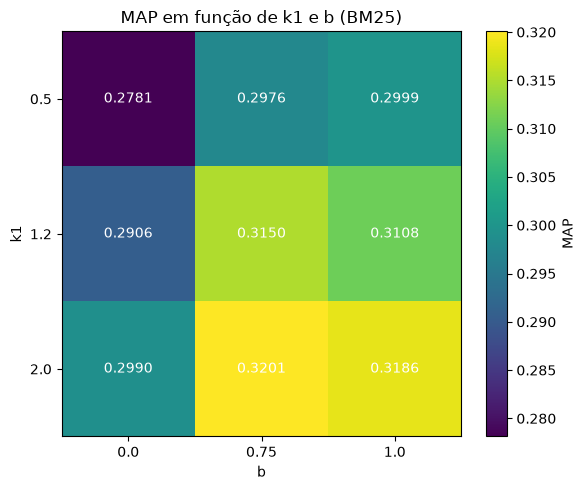

In [29]:
# Heatmap de MAP em função de k1 e b, para visualizar o efeito conjunto dos dois parâmetros
pivot_param = df_parametros.pivot(index='k1', columns='b', values='MAP')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pivot_param.values, cmap='viridis', aspect='auto')

ax.set_xticks(range(len(pivot_param.columns)))
ax.set_xticklabels(pivot_param.columns)
ax.set_yticks(range(len(pivot_param.index)))
ax.set_yticklabels(pivot_param.index)
ax.set_xlabel('b')
ax.set_ylabel('k1')
ax.set_title('MAP em função de k1 e b (BM25)')

for i in range(pivot_param.shape[0]):
    for j in range(pivot_param.shape[1]):
        ax.text(j, i, f"{pivot_param.values[i, j]:.4f}", ha='center', va='center', color='white')

fig.colorbar(im, ax=ax, label='MAP')
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'grafico_heatmap_k1_b.png'), dpi=150)
plt.show()


### Encontrando uma consulta sensível à variação de $b$

Buscamos programaticamente, entre todas as consultas, aquela em que alterar apenas $b$ de `0.0` (sem normalização de tamanho) para `1.0` (normalização total), mantendo $k_1=1.2$ fixo (valor da grade), causa a maior mudança no Top 5 do ranking (maior diferença simétrica entre os conjuntos, que vai de 0 a 10). Para relacionar a mudança ao comprimento dos documentos, mostramos o tamanho de cada documento em tokens comparado ao comprimento médio do corpus (`avgdl`), e o comprimento médio dos documentos no Top 10 para cada valor de $b$.

In [30]:
# k1 fixo em 1.2 (valor da grade); variamos apenas b entre 0.0 (sem normalização) e 1.0 (normalização total)
k1_fixo = 1.2
bm25_b0 = BM25Modelo(docs_df['tokens_both'].tolist(), k1=k1_fixo, b=0.0)
bm25_b1 = BM25Modelo(docs_df['tokens_both'].tolist(), k1=k1_fixo, b=1.0)

maior_diferenca = -1
query_alvo_id = None

for _, q_row in queries_df.iterrows():
    q_id = str(q_row['query_id'])
    q_tokens = q_row['tokens_both']

    if q_id not in relevantes_reais:
        continue

    r_b0 = [str(doc_id) for doc_id, _ in bm25_b0.buscar(q_tokens, docs_df, top_n=5)]
    r_b1 = [str(doc_id) for doc_id, _ in bm25_b1.buscar(q_tokens, docs_df, top_n=5)]

    if len(r_b0) < 5 or len(r_b1) < 5:
        continue

    diferenca = len(set(r_b0).symmetric_difference(set(r_b1)))
    if diferenca > maior_diferenca:
        maior_diferenca = diferenca
        query_alvo_id = q_id

info_query = queries_df[queries_df['query_id'] == query_alvo_id].iloc[0]
rel_docs_alvo = relevantes_reais.get(query_alvo_id, set())

print(f"Consulta selecionada: Query ID {query_alvo_id} (diferença simétrica entre os Top 5 = {maior_diferenca}, máximo possível = 10)")
print(f"Texto: {info_query['text'].strip()}")
print(f"Tokens: {info_query['tokens_both']}")
print(f"Documentos relevantes (qrels): {sorted(rel_docs_alvo, key=int)}")

avgdl = bm25_b0.avgdl
for rotulo, modelo in [('b=0.0 (sem normalização de tamanho)', bm25_b0), ('b=1.0 (normalização total de tamanho)', bm25_b1)]:
    ranking = modelo.buscar(info_query['tokens_both'], docs_df)
    ap = calcular_metricas_completas(ranking, rel_docs_alvo, graus_reais.get(query_alvo_id, {}))['ap']
    print(f"\nTop 5 com {rotulo} | AP = {ap:.4f}")
    for pos, (doc_id, score) in enumerate(ranking[:5], 1):
        tamanho = modelo.doc_lengths[indice_doc[doc_id]]
        titulo = docs_df['title'].iloc[indice_doc[doc_id]].strip().replace(chr(10), ' ')[:60]
        marcador = f"[{rotulo_relevancia(query_alvo_id, doc_id)}]"
        print(f"  {pos}. Doc {doc_id:>5s} | |d|={tamanho:4d} tokens ({tamanho / avgdl:.2f} x avgdl) | {marcador:18s} | {titulo}")

# Efeito global de b: comprimento médio dos documentos no Top 10, considerando todas as consultas
print(f"\nComprimento médio dos documentos no Top 10 (k1={k1_fixo}); avgdl = {avgdl:.1f} tokens")
for b_val in b_valores:
    modelo_b = BM25Modelo(docs_df['tokens_both'].tolist(), k1=k1_fixo, b=b_val)
    comprimentos = [modelo_b.doc_lengths[indice_doc[doc_id]]
                    for q_tokens in queries_df['tokens_both']
                    for doc_id, _ in modelo_b.buscar(q_tokens, docs_df, top_n=10)]
    print(f"  b={b_val}: {np.mean(comprimentos):.1f} tokens")
comprimento_relevantes = np.mean([len(docs_df['tokens_both'].iloc[indice_doc[d]])
                                  for q_id in relevantes_reais for d in relevantes_reais[q_id]])
print(f"Comprimento médio dos documentos relevantes (por par consulta-documento): {comprimento_relevantes:.1f} tokens")

Consulta selecionada: Query ID 67 (diferença simétrica entre os Top 5 = 10, máximo possível = 10)
Texto: can series expansions be found for the boundary layer on a flat plate in
a shear flow .
Tokens: ['seri', 'expans', 'found', 'boundari', 'layer', 'flat', 'plate', 'shear', 'flow']
Documentos relevantes (qrels): ['2', '3', '4', '128', '180', '323', '324', '389', '393', '394', '629', '659', '664', '1302']

Top 5 com b=0.0 (sem normalização de tamanho) | AP = 0.2067
  1. Doc     9 | |d|= 217 tokens (2.11 x avgdl) | [não relevante]    | transition studies and skin friction measurements on an insu
  2. Doc     2 | |d|= 126 tokens (1.22 x avgdl) | [RELEVANTE g=1]    | simple shear flow past a flat plate in an incompressible flu
  3. Doc  1107 | |d|= 159 tokens (1.54 x avgdl) | [não relevante]    | the flow field over blunted flat plates and its effect on tu
  4. Doc    72 | |d|= 175 tokens (1.70 x avgdl) | [não relevante]    | boundary layer behind shock or thin expansion wave moving in
  

  b=0.0: 146.3 tokens


  b=0.75: 109.7 tokens


  b=1.0: 101.3 tokens
Comprimento médio dos documentos relevantes (por par consulta-documento): 106.8 tokens


In [31]:
# Efeito de k1: fator de saturação tf*(k1+1)/(tf+k1) para um documento de tamanho médio (|d| = avgdl)
tabela_saturacao = pd.DataFrame(
    {f'tf={tf}': [tf * (k1 + 1) / (tf + k1) for k1 in k1_valores] for tf in [1, 2, 3, 5, 10]},
    index=[f'k1={k1}' for k1 in k1_valores]
)
display(tabela_saturacao.round(2))

# Frequência (no documento) dos termos da consulta que casam nos Top 10 do BM25 (k1=1.2, b=0.75)
bm25_referencia = BM25Modelo(docs_df['tokens_both'].tolist(), k1=1.2, b=0.75)
tfs_casados = []
for q_tokens in queries_df['tokens_both']:
    for doc_id, _ in bm25_referencia.buscar(q_tokens, docs_df, top_n=10):
        tf_doc = bm25_referencia.doc_term_freqs[indice_doc[doc_id]]
        tfs_casados += [tf_doc[t] for t in set(q_tokens) if tf_doc[t] > 0]
tfs_casados = np.array(tfs_casados)
print(f"Termos casados no Top 10: tf médio = {tfs_casados.mean():.2f} | tf = 1: {np.mean(tfs_casados == 1):.0%} | "
      f"tf >= 3: {np.mean(tfs_casados >= 3):.0%}")

,tf=1,tf=2,tf=3,tf=5,tf=10
k1=0.5,1.0,1.20,1.29,1.36,1.43
k1=1.2,1.0,1.38,1.57,1.77,1.96
k1=2.0,1.0,1.50,1.80,2.14,2.50


Termos casados no Top 10: tf médio = 3.02 | tf = 1: 31% | tf >= 3: 50%


### Discussão do efeito dos parâmetros

- **$b$ (normalização por comprimento) é o parâmetro de maior efeito.** Para todo $k_1$, $b = 0$ é o pior valor (com $k_1 = 1{,}2$: MAP 0,291, contra 0,315 com $b = 0{,}75$). Sem normalização, documentos longos acumulam mais ocorrências dos termos da consulta e dominam o topo: o comprimento médio dos documentos no Top 10 é 146,3 tokens com $b = 0$, contra 109,7 com $b = 0{,}75$ e 101,3 com $b = 1$ (avgdl = 102,9; os documentos relevantes têm 106,8 tokens em média). Com $k_1 \geq 1{,}2$, $b = 1$ fica um pouco abaixo de $b = 0{,}75$, porque penaliza demais documentos longos que são relevantes (como o doc 662 da Q95). Com $k_1 = 0{,}5$ a ordem se inverte e $b = 1$ é o melhor: o termo de normalização aparece multiplicado por $k_1$ no denominador, então com $k_1$ pequeno o efeito de $b$ enfraquece, e uma penalização maior compensa.
- **$k_1$ (saturação): quanto maior, melhor nesta coleção.** Com $b = 0{,}75$, o MAP sobe de 0,298 ($k_1 = 0{,}5$) para 0,315 ($k_1 = 1{,}2$) e 0,320 ($k_1 = 2{,}0$). Com $k_1 = 0{,}5$ o BM25 fica quase binário: um termo com tf = 3 vale só 1,29× um termo com tf = 1, contra 1,8× com $k_1 = 2{,}0$ (tabela acima). No Cranfield, a repetição é informativa: são resumos curtos, em que um termo repetido costuma ser o assunto central, e o título duplicado garante tf ≥ 2 aos termos do título — metade dos termos casados no Top 10 tem tf ≥ 3. Saturar cedo joga essa informação fora. O melhor valor está na borda da grade ($k_1 = 2{,}0$), mas o ganho já diminui (+0,017 de 0,5 para 1,2; +0,005 de 1,2 para 2,0).
- **Melhor e pior combinação:** $k_1 = 2{,}0$, $b = 0{,}75$ (MAP 0,320, P@10 0,248, NDCG@10 0,385) e $k_1 = 0{,}5$, $b = 0$ (MAP 0,278, P@10 0,208, NDCG@10 0,333). MAP, P@10 e NDCG@10 ordenam as combinações quase da mesma forma.
- **Consulta sensível a $b$ (Q67):** com $b = 0$ o Top 5 tem documentos de 101 a 217 tokens e só 1 relevante (AP = 0,207); com $b = 1$ os cinco são relevantes e têm de 25 a 57 tokens (AP = 0,552). Os relevantes da Q67 são textos curtos e específicos; sem normalização, documentos longos sobre camada-limite em geral acumulam mais ocorrências dos termos comuns da consulta (*boundari*, *layer*, *flow*, *plate*) e passam à frente.

## Etapa 7: Modificação de Consultas e Análise de Impacto

Selecionamos 5 consultas da coleção Cranfield e criamos manualmente uma versão alternativa de cada uma. A versão original é lida diretamente de `queries_df` (idêntica à usada nas demais etapas). As versões original e modificada são executadas no Modelo Vetorial e no BM25 (configuração `both`, BM25 com $k_1=2.0,\ b=0.75$ — melhor combinação encontrada na Etapa 6). Para cada modelo, comparamos a **sobreposição do Top 10**, **quais documentos entraram e saíram** do Top 10 (com sua relevância) e a variação de **AP** e **P@10**. Como a consulta modificada expressa a mesma necessidade de informação, os qrels da consulta original continuam válidos para avaliá-la.

### Estratégia de modificação das consultas
1. **Query 1** (*similarity laws ... aeroelastic models of heated high speed aircraft*): reformulação com termos técnicos de ensaio (*dynamic scale, wind tunnel testing, thermo-aeroelastic, structures*), substituindo *models*, *aircraft* e *constructing*.
2. **Query 3** (*heat conduction in composite slabs*): consulta tornada mais específica (*analytical transient temperature distribution ... multilayer*).
3. **Query 15** (*material properties of photoelastic materials*): remoção da repetição de *materials* e troca por termos mais específicos (*mechanical and optical properties ... specimens*).
4. **Query 95** (*heat transfer distribution around a hemisphere*): generalização — *hemisphere* substituído pela classe mais ampla *aerodynamic blunt bodies in hypersonic flow*.
5. **Query 173** (*lyapunov's method ... periodic coefficients*): remoção dos termos de contexto (*references, method, coefficients*), mantendo só os termos centrais.

In [32]:
# As versões originais são lidas de queries_df, para serem idênticas às consultas avaliadas nas demais etapas
queries_custom = [
    {'query_id': '1', 'descricao': 'Reformulação com termos técnicos (expansão + substituição)',
     'modificada': 'what dynamic scale similarity laws govern wind tunnel testing of thermo-aeroelastic heated high speed structures .'},
    {'query_id': '3', 'descricao': 'Tornando a consulta mais específica',
     'modificada': 'analytical transient temperature distribution and heat conduction problems in multilayer composite slabs .'},
    {'query_id': '15', 'descricao': 'Remoção de termo repetido + termos mais específicos',
     'modificada': 'mechanical and optical properties of photoelastic specimens .'},
    {'query_id': '95', 'descricao': 'Generalização (termo específico -> classe mais ampla)',
     'modificada': 'theoretical heat transfer distribution around aerodynamic blunt bodies in hypersonic flow .'},
    {'query_id': '173', 'descricao': 'Remoção de termos de contexto (foco nos termos centrais)',
     'modificada': 'lyapunov stability linear differential equations periodic .'},
]

bm25_otimo = BM25Modelo(docs_df['tokens_both'].tolist(), k1=2.0, b=0.75)

def obter_top_10(ranking):
    return [str(doc_id) for doc_id, _ in ranking[:10]]

modelos_modificacao = [
    ('MODELO VETORIAL', 'vetorial', lambda tokens: buscar_modelo_vetorial(tokens, 'both')),
    ('BM25 (k1=2.0, b=0.75)', 'bm25', lambda tokens: bm25_otimo.buscar(tokens, docs_df)),
]

resultados_modificacao = []

for q_info in queries_custom:
    q_id = q_info['query_id']
    q_row = queries_df[queries_df['query_id'] == q_id].iloc[0]
    rel_docs = relevantes_reais.get(q_id, set())
    graus_query = graus_reais.get(q_id, {})

    tokens_orig = q_row['tokens_both']
    tokens_mod = preprocess(q_info['modificada'], remove_stopwords=True, use_stemming=True)

    print("=" * 100)
    print(f"QUERY ID: {q_id} ({q_info['descricao']})")
    print(f"Original:   {q_row['text'].strip()}")
    print(f"Modificada: {q_info['modificada']}")
    print(f"Tokens originais:   {tokens_orig}")
    print(f"Tokens modificados: {tokens_mod}")

    linha = {'query_id': q_id, 'descricao': q_info['descricao'],
             'consulta_original': q_row['text'].strip(), 'consulta_modificada': q_info['modificada']}

    for rotulo, sufixo, buscar in modelos_modificacao:
        ranking_orig, ranking_mod = buscar(tokens_orig), buscar(tokens_mod)
        top10_orig, top10_mod = obter_top_10(ranking_orig), obter_top_10(ranking_mod)
        m_orig = calcular_metricas_completas(ranking_orig, rel_docs, graus_query)
        m_mod = calcular_metricas_completas(ranking_mod, rel_docs, graus_query)

        intersecao = len(set(top10_orig) & set(top10_mod))
        sairam = [d for d in top10_orig if d not in top10_mod]
        entraram = [d for d in top10_mod if d not in top10_orig]

        print(f"-> {rotulo}: Top10 original x modificado = {intersecao}/10 de sobreposição | "
              f"AP: {m_orig['ap']:.4f} -> {m_mod['ap']:.4f} | P@10: {m_orig['precision']:.1f} -> {m_mod['precision']:.1f}")
        print(f"   Saíram do Top 10:   {[(d, rotulo_relevancia(q_id, d)) for d in sairam]}")
        print(f"   Entraram no Top 10: {[(d, rotulo_relevancia(q_id, d)) for d in entraram]}")

        linha.update({
            f'overlap_top10_{sufixo}': intersecao,
            f'AP_{sufixo}_original': m_orig['ap'], f'AP_{sufixo}_modificada': m_mod['ap'],
            f'P10_{sufixo}_original': m_orig['precision'], f'P10_{sufixo}_modificada': m_mod['precision'],
            f'saiu_top10_{sufixo}': ' '.join(sairam), f'entrou_top10_{sufixo}': ' '.join(entraram),
        })
    print()
    resultados_modificacao.append(linha)

df_modificacao = pd.DataFrame(resultados_modificacao)
df_modificacao.to_csv(os.path.join(DIR_RESULTADOS, 'resultados_modificacao_consultas.csv'), index=False)
display(df_modificacao[['query_id', 'descricao', 'overlap_top10_vetorial', 'AP_vetorial_original', 'AP_vetorial_modificada',
                        'overlap_top10_bm25', 'AP_bm25_original', 'AP_bm25_modificada']])

QUERY ID: 1 (Reformulação com termos técnicos (expansão + substituição))
Original:   what similarity laws must be obeyed when constructing aeroelastic models
of heated high speed aircraft .
Modificada: what dynamic scale similarity laws govern wind tunnel testing of thermo-aeroelastic heated high speed structures .
Tokens originais:   ['similar', 'law', 'must', 'obey', 'construct', 'aeroelast', 'model', 'heat', 'high', 'speed', 'aircraft']
Tokens modificados: ['dynam', 'scale', 'similar', 'law', 'govern', 'wind', 'tunnel', 'test', 'thermo', 'aeroelast', 'heat', 'high', 'speed', 'structur']
-> MODELO VETORIAL: Top10 original x modificado = 6/10 de sobreposição | AP: 0.3153 -> 0.2415 | P@10: 0.6 -> 0.4
   Saíram do Top 10:   [('51', 'RELEVANTE g=3'), ('875', 'RELEVANTE g=2'), ('435', 'não relevante'), ('56', 'RELEVANTE g=3')]
   Entraram no Top 10: [('876', 'RELEVANTE g=3'), ('141', 'não relevante'), ('516', 'não relevante'), ('874', 'não relevante')]
-> BM25 (k1=2.0, b=0.75): Top10 orig

-> BM25 (k1=2.0, b=0.75): Top10 original x modificado = 8/10 de sobreposição | AP: 0.6888 -> 0.7752 | P@10: 0.7 -> 0.7
   Saíram do Top 10:   [('579', 'não relevante'), ('542', 'não relevante')]
   Entraram no Top 10: [('981', 'não relevante'), ('582', 'não relevante')]



QUERY ID: 15 (Remoção de termo repetido + termos mais específicos)
Original:   material properties of photoelastic materials .
Modificada: mechanical and optical properties of photoelastic specimens .
Tokens originais:   ['materi', 'properti', 'photoelast', 'materi']
Tokens modificados: ['mechan', 'optic', 'properti', 'photoelast', 'specimen']
-> MODELO VETORIAL: Top10 original x modificado = 2/10 de sobreposição | AP: 0.6667 -> 1.0000 | P@10: 0.2 -> 0.2
   Saíram do Top 10:   [('1097', 'não relevante'), ('761', 'não relevante'), ('553', 'não relevante'), ('1096', 'não relevante'), ('1025', 'não relevante'), ('866', 'não relevante'), ('1117', 'não relevante'), ('1098', 'não relevante')]
   Entraram no Top 10: [('507', 'não relevante'), ('1268', 'não relevante'), ('881', 'não relevante'), ('1257', 'não relevante'), ('1056', 'não relevante'), ('836', 'não relevante'), ('1099', 'não relevante'), ('405', 'não relevante')]
-> BM25 (k1=2.0, b=0.75): Top10 original x modificado = 3/10 de sobr

-> BM25 (k1=2.0, b=0.75): Top10 original x modificado = 7/10 de sobreposição | AP: 0.8333 -> 0.8333 | P@10: 0.2 -> 0.2
   Saíram do Top 10:   [('767', 'não relevante'), ('1054', 'não relevante'), ('813', 'não relevante')]
   Entraram no Top 10: [('931', 'não relevante'), ('515', 'não relevante'), ('1119', 'não relevante')]



,query_id,descricao,overlap_top10_vetorial,AP_vetorial_original,AP_vetorial_modificada,overlap_top10_bm25,AP_bm25_original,AP_bm25_modificada
0,1,Reformulação com termos técnicos (expansão + s...,6,0.315333,0.241513,5,0.242504,0.174051
1,3,Tornando a consulta mais específica,9,0.687354,0.677812,8,0.688839,0.775187
2,15,Remoção de termo repetido + termos mais especí...,2,0.666667,1.000000,3,1.000000,1.000000
3,95,Generalização (termo específico -> classe mais...,1,0.750000,0.312500,3,0.416667,0.308824
4,173,Remoção de termos de contexto (foco nos termos...,8,0.583333,0.500000,7,0.833333,0.833333


### Análise da modificação de consultas

| Consulta | Estratégia | Vetorial: AP (sobreposição Top 10) | BM25: AP (sobreposição Top 10) |
|---|---|---|---|
| Q1 | reformulação (expansão + substituição) | 0,315 → 0,242 (6/10) | 0,243 → 0,174 (5/10) |
| Q3 | mais específica | 0,687 → 0,678 (9/10) | 0,689 → 0,775 (8/10) |
| Q15 | remove repetição + termos específicos | 0,667 → 1,000 (2/10) | 1,000 → 1,000 (3/10) |
| Q95 | generalização | 0,750 → 0,313 (1/10) | 0,417 → 0,309 (3/10) |
| Q173 | remove termos de contexto | 0,583 → 0,500 (8/10) | 0,833 → 0,833 (7/10) |

- **Q1:** a nova versão removeu *model*, *aircraft* e *construct* e acrescentou termos de ensaio em túnel (*dynamic, scale, wind tunnel testing, structures*). O relevante doc 51 (*theory of aircraft structural models...*, com *aircraft* tf = 10) caiu do 1º lugar para o 21º (Vetorial) e o 22º (BM25). Entraram documentos sobre ensaios e medições em voo e em túnel de vento, quase todos não relevantes (docs 141, 516, 874, 790, 1305); só o doc 876 (*on flutter testing in high speed wind tunnels*) é relevante. É um desvio de tópico (*topic drift*): os termos acrescentados descrevem outro aspecto do assunto.
- **Q3:** tornar a consulta mais específica (*analytical transient temperature distribution ... multilayer*) quase não mexe no Top 10 (9/10 e 8/10 em comum) e mantém 7 relevantes, mas no BM25 reordena o topo: os relevantes 6 e 5 sobem para 1º e 2º, acima do doc-fonte 485, e o AP sobe de 0,689 para 0,775.
- **Q15:** a consulta original repete *materials*, que por isso tem peso dobrado nos dois modelos e atrai documentos sobre materiais em geral (ablação de materiais vítreos, flambagem por fluência). A versão modificada remove a repetição e acrescenta *mechanical, optical, specimens*: no Vetorial, o relevante 463 sobe de 6º para 2º e o AP vai a 1,0. No BM25, os dois relevantes já estavam em 1º e 2º; a baixa sobreposição (3/10) vem só da troca de documentos não relevantes nas posições 3 a 10.
- **Q95:** generalizar *hemisphere* para *aerodynamic blunt bodies in hypersonic flow* foi a pior modificação. Removeu o termo mais discriminante da consulta (*hemispher*, df = 31) e acrescentou termos frequentes no corpus. O Top 10 do Vetorial mudou quase inteiro (1/10), e o relevante 662 caiu de 1º para 16º no Vetorial e de 2º para 17º no BM25.
- **Q173:** remover os termos de contexto (*references, method, coefficients*) não muda o AP do BM25, mas no Vetorial o relevante 451 cai de 3º para 4º: como ele escreve *liapunov*, depende justamente de *method* e *coeffici* para casar com a consulta.

**Conclusões:** retirar termos discriminantes (Q95) ou termos que os relevantes usam (Q1, Q173) prejudica; acrescentar termos específicos presentes nos relevantes (Q3, Q15) ajuda. O Vetorial foi mais sensível às modificações (variação média de |ΔAP| de 0,19, contra 0,05 no BM25). Nossa hipótese: sem saturação, o cosseno depende muito de poucos termos repetidos (como *hemispher* no doc 662, ou *materi* duplicado na consulta 15), então tirar ou acrescentar um desses termos reordena mais o ranking. No BM25, cada termo contribui de forma saturada e o score depende mais de quantos termos distintos casam.

## Etapa 8: Análise de Erros (Falsos Positivos e Falsos Negativos)

Investigamos o comportamento do **BM25** (configuração `both`, $k_1=2.0,\ b=0.75$ — melhor combinação da Etapa 6) para identificar falhas sistemáticas de correspondência léxica:
- **Falsos Positivos (FP):** documentos não relevantes (julgamento -1 ou não julgados) que aparecem no **Top 3** do ranking. Separamos os que são o documento-fonte da consulta (julgamento -1, ver Etapa 5), que têm natureza diferente dos demais.
- **Falsos Negativos (FN):** documentos relevantes de grau 1 ou 2 (os mais relevantes na escala do Cranfield: resposta completa e alto grau de relevância) que ficam **fora do Top 10**.

In [33]:
falsos_positivos_candidatos = []
falsos_negativos_candidatos = []

for _, q_row in queries_df.iterrows():
    q_id = str(q_row['query_id'])
    q_tokens = q_row['tokens_both']

    if q_id not in relevantes_reais:
        continue

    qrels_da_query = qrels_df[qrels_df['query_id'] == q_id]
    dict_relevancias = pd.Series(qrels_da_query.relevance.values, index=qrels_da_query.doc_id).to_dict()

    ranking = bm25_otimo.buscar(q_tokens, docs_df)
    ranking_ids = [str(doc_id) for doc_id, _ in ranking]

    # Falsos Positivos no Top 3
    for pos, doc_id in enumerate(ranking_ids[:3], 1):
        relevancia_real = dict_relevancias.get(doc_id, -1)
        if relevancia_real < 1:  # não relevante ou não julgado
            falsos_positivos_candidatos.append({
                'query_id': q_id, 'query_text': q_row['text'].strip(),
                'doc_id': doc_id, 'posicao_ranking': pos, 'score_bm25': ranking[pos - 1][1],
                'doc_fonte': doc_id == doc_fonte[q_id]
            })

    # Falsos Negativos: relevância alta (grau 1 ou 2 = as mais relevantes na escala do Cranfield) fora do Top 10
    for doc_id, rel in dict_relevancias.items():
        if rel in (1, 2):
            if doc_id not in ranking_ids[:10]:
                pos_real = ranking_ids.index(doc_id) + 1 if doc_id in ranking_ids else None
                falsos_negativos_candidatos.append({
                    'query_id': q_id, 'query_text': q_row['text'].strip(),
                    'doc_id': doc_id, 'posicao_real': pos_real if pos_real else 'Não recuperado (score 0)',
                    'relevancia_original': rel
                })

df_fp = pd.DataFrame(falsos_positivos_candidatos)
df_fn = pd.DataFrame(falsos_negativos_candidatos)
df_fp.to_csv(os.path.join(DIR_RESULTADOS, 'falsos_positivos_bm25.csv'), index=False)
df_fn.to_csv(os.path.join(DIR_RESULTADOS, 'falsos_negativos_bm25.csv'), index=False)

print(f"Encontrados {len(df_fp)} candidatos a Falso Positivo no Top 3 (em todas as consultas): "
      f"{df_fp['doc_fonte'].sum()} são o documento-fonte da consulta (-1) e {(~df_fp['doc_fonte']).sum()} são não julgados.")
nao_recuperados = (df_fn['posicao_real'] == 'Não recuperado (score 0)').sum()
print(f"Encontrados {len(df_fn)} candidatos a Falso Negativo fora do Top 10 (em todas as consultas): "
      f"{nao_recuperados} nem foram recuperados (nenhum termo em comum com a consulta).")


Encontrados 416 candidatos a Falso Positivo no Top 3 (em todas as consultas): 130 são o documento-fonte da consulta (-1) e 286 são não julgados.
Encontrados 287 candidatos a Falso Negativo fora do Top 10 (em todas as consultas): 22 nem foram recuperados (nenhum termo em comum com a consulta).


In [34]:
print("=== AMOSTRA DE FALSOS POSITIVOS (FP) ===")
display(df_fp.head(5))

print("\n=== AMOSTRA DE FALSOS NEGATIVOS (FN) ===")
display(df_fn.head(5))


=== AMOSTRA DE FALSOS POSITIVOS (FP) ===


,query_id,query_text,doc_id,posicao_ranking,score_bm25,doc_fonte
0,1,what similarity laws must be obeyed when const...,486,2,23.398197,True
1,3,what problems of heat conduction in composite ...,485,1,26.641919,True
2,4,can a criterion be developed to show empirical...,488,2,38.002390,True
3,4,can a criterion be developed to show empirical...,1061,3,28.317283,False
4,5,what chemical kinetic system is applicable to ...,103,1,17.402577,False



=== AMOSTRA DE FALSOS NEGATIVOS (FN) ===


,query_id,query_text,doc_id,posicao_real,relevancia_original
0,1,what similarity laws must be obeyed when const...,29,37,2
1,1,what similarity laws must be obeyed when const...,31,Não recuperado (score 0),2
2,1,what similarity laws must be obeyed when const...,57,299,2
3,1,what similarity laws must be obeyed when const...,378,46,2
4,1,what similarity laws must be obeyed when const...,859,258,2


### 8.1 Inspeção textual dos casos de erro

Escolhemos, a partir de `df_fp` e `df_fn`, três falsos positivos e dois falsos negativos que ilustram mecanismos de erro diferentes (a especificação pede ao menos dois e um, respectivamente). Para cada um, mostramos o texto do documento e a contribuição de cada termo da consulta no score do BM25 ($k_1 = 2{,}0$, $b = 0{,}75$), além da posição do documento no Modelo Vetorial.

In [35]:
def exibir_detalhes_doc(doc_id_alvo):
    doc = docs_df.iloc[indice_doc[str(doc_id_alvo)]]
    print(f"DOCUMENTO ID: {doc_id_alvo}")
    print(f"Título: {doc['title'].strip()}")
    print(f"Texto: {doc['text'].strip()[:600]}...")

# Exemplos escolhidos a partir de df_fp e df_fn (BM25 com k1=2.0, b=0.75), cobrindo mecanismos de erro diferentes
exemplos_erro = [
    ('FALSO POSITIVO 1 - documento-fonte da consulta (julgamento -1)', '1', '486'),
    ('FALSO POSITIVO 2 - coincidência lexical em outro domínio', '28', '367'),
    ('FALSO POSITIVO 3 - documento não julgado, mas tematicamente próximo', '37', '186'),
    ('FALSO NEGATIVO 1 - resposta completa (grau 1) fora do Top 10', '94', '24'),
    ('FALSO NEGATIVO 2 - grau 2 fora do Top 10', '1', '29'),
]

for rotulo, q_id, doc_id in exemplos_erro:
    print("=" * 100)
    print(rotulo)
    exibir_detalhes_doc(doc_id)
    decompor_scores(q_id, [doc_id], bm25_otimo)

FALSO POSITIVO 1 - documento-fonte da consulta (julgamento -1)
DOCUMENTO ID: 486
Título: similarity laws for aerothermoelastic testing .
Texto: similarity laws for aerothermoelastic testing .
  the similarity laws for aerothermoelastic testing are presented
in the range .  these are obtained by
making nondimensional the appropriate governing equations of
the individual external aerodynamic flow, heat conduction to
the interior, and stress-deflection problems which make up the
combined aerothermoelastic problem .
  for the general aerothermoelastic model, where the model is
placed in a high-stagnation-temperature wind tunnel, similitude
is shown to be very difficult to achieve for a scale ratio other
than unity .  the primary conflict ...
Query 1: what similarity laws must be obeyed when constructing aeroelastic models
of heated high speed aircraft .
Tokens: ['similar', 'law', 'must', 'obey', 'construct', 'aeroelast', 'model', 'heat', 'high', 'speed', 'aircraft'] | BM25 com k1=2.0, b=0.

Query 94: what is the theoretical heat transfer rate at the stagnation point of a
blunt body .
Tokens: ['theoret', 'heat', 'transfer', 'rate', 'stagnat', 'point', 'blunt', 'bodi'] | BM25 com k1=2.0, b=0.75

  Doc 24 [RELEVANTE g=1] | |d|=154 tokens (1.50 x avgdl) | posição Vetorial=21, BM25=14 | theory of stagnation point heat transfer in dissociated air .
   termo  tf_consulta  tf_doc  df  idf_bm25  contrib_bm25  contrib_cosseno
    heat            1       4 306      1.52          2.70           0.0415
transfer            1       4 208      1.91          3.39           0.0552
    rate            1       3 145      2.26          3.55           0.0522
 stagnat            1       5 134      2.34          4.54           0.0913
   point            1       5 235      1.78          3.45           0.0633
    bodi            1       1 293      1.56          1.25           0.0107
  total: BM25 = 18.88 | cosseno = 0.3142
  Termos da consulta ausentes no documento (termo, df): [('theoret', 235), 

### 8.2 Discussão dos erros encontrados

**Visão geral.** Dos 416 falsos positivos no Top 3, 130 (31%) são o documento-fonte da consulta (julgamento -1) e 286 são documentos não julgados. Dos 287 falsos negativos (relevantes de grau 1 ou 2 fora do Top 10), 22 nem são recuperados, porque não têm nenhum termo em comum com a consulta.

**FP1 — doc 486 na Q1 (2º lugar): documento-fonte.** *Similarity laws for aerothermoelastic testing* casa 7 dos 11 termos da consulta, incluindo os raros *law* (df = 53, tf = 4) e *aeroelast* (df = 18), além de *similar* e *model* com tf = 5. É o documento lexicalmente mais próximo da consulta e, pelo padrão dos qrels, o artigo a partir do qual a pergunta foi formulada. Pela regra da especificação ele conta como não relevante; o "erro" não é do modelo, mas da forma como a coleção marca o artigo-fonte. Como isso acontece em 31% dos falsos positivos do Top 3, reduz a P@10, o MAP e o MRR dos dois modelos de forma sistemática.

**FP2 — doc 367 na Q28 (1º lugar): coincidência lexical em outro domínio.** A consulta pede aplicações da *linear theory design of curved wings* (aerodinâmica). O doc 367 é sobre projeto de sistemas de controle pelo método de Lyapunov e casa *applic*, *linear* (tf = 2), *theori* (tf = 2) e *design* (tf = 3), todos em outro sentido, sem conter *curv* nem *wing*, os termos que definem o domínio. Com 74 tokens (abaixo do avgdl), recebe pouca penalização de tamanho, e a soma de quatro termos de IDF médio (12,28) supera os documentos sobre asas. No Vetorial, o mesmo documento fica só em 27º. O BM25 é *bag-of-words*: não modela que "linear theory" em aerodinâmica e "linear systems" em controle são coisas diferentes, nem exige a presença dos termos de domínio.

**FP3 — doc 186 na Q37 (1º lugar): lacuna nos julgamentos.** *Base pressure in supersonic flow* discute exatamente "the problem of accurately predicting the pressure ... at the base of bodies in supersonic flow", e a consulta pede *theoretical methods for predicting base pressure*. Ele não está nos qrels. Os julgamentos do Cranfield não são exaustivos, então parte dos falsos positivos provavelmente é relevante e só não foi julgada.

**FN1 — doc 24 na Q94 (14º lugar, grau 1 = resposta completa).** *Theory of stagnation point heat transfer in dissociated air* responde à pergunta (*theoretical heat transfer rate at the stagnation point of a blunt body*), mas perde dois termos: *blunt* não aparece, e *theoretical* (→ *theoret*) não casa com *theory* (→ *theori*), porque o Porter não agrupa as duas formas. Além disso, o documento é longo (154 tokens, 1,5× avgdl), e $b = 0{,}75$ reduz a contribuição dos termos que casam (*stagnat* e *point* com tf = 5). Documentos mais curtos que contêm *blunt* e *bodi* passam à frente.

**FN2 — doc 29 na Q1 (37º lugar, grau 2).** O documento descreve "simple models intended to simulate parts or the whole of an aircraft structure" — a ideia de semelhança expressa com outras palavras. Não contém *similar*, *law* nem *aeroelast*, os termos mais discriminantes da consulta, e casa apenas *model*, *heat* e *aircraft* (score 9,92, contra 25,72 do 1º colocado): um descompasso vocabular parcial.

**Padrões:** (i) documentos-fonte e lacunas de julgamento inflam os falsos positivos sem que o modelo esteja necessariamente errado; (ii) casar termos genéricos usados em outro sentido gera falsos positivos reais; (iii) o descompasso vocabular e as limitações do stemmer (*theory/theoretical*, *sudden/suddenly*) são a principal causa dos falsos negativos, agravada pela normalização de comprimento em documentos longos.

## Considerações Finais

1. **Pré-processamento:** stopwords + stemming (`both`) é a melhor configuração para os dois modelos (MAP 0,319 no BM25 e 0,307 no Vetorial, +13% e +11% sobre `basico`). O stemming contribui mais que a remoção de stopwords. Duplicar o título (o efeito real de indexar `title + text`) também melhora os dois modelos.
2. **Vetorial vs. BM25:** o BM25 é ligeiramente melhor na média (MAP 0,319 vs. 0,307; MRR 0,551 vs. 0,534; P@10 igual, 0,243), mas vence em 121 consultas e perde em 96. As maiores diferenças se explicam pela saturação de tf (o BM25 impede que termos comuns repetidos dominem), pela cobertura (o BM25 soma contribuições de muitos termos) e pela normalização de comprimento (o cosseno com tf bruto favorece documentos que concentram ou repetem muito os termos da consulta).
3. **Parâmetros do BM25:** $b$ tem o maior efeito — sem normalização ($b = 0$), documentos longos dominam o topo e o MAP cai para todo $k_1$. Valores maiores de $k_1$ ajudam nesta coleção, onde a repetição de termos é informativa. A melhor combinação da grade foi $k_1 = 2{,}0$, $b = 0{,}75$ (MAP 0,320).
4. **Erros:** o descompasso vocabular (Q13, Q22) e as limitações do stemmer são a principal causa de falsos negativos, e nenhum dos dois modelos lexicais os resolve. Parte dos falsos positivos vem da própria coleção: o documento-fonte de cada consulta (julgamento -1) aparece em 1º lugar em 42% das consultas no BM25 e 37% no Vetorial, e há documentos relevantes que não foram julgados.
5. **Reformulação de consultas:** remover termos discriminantes, ou termos usados pelos relevantes, prejudica; acrescentar termos específicos ajuda. O Vetorial foi mais sensível às modificações.

**Limitações:** o pré-processamento e os parâmetros "ótimos" foram escolhidos nas mesmas consultas avaliadas (resultados levemente otimistas), e as diferenças entre os modelos não foram testadas estatisticamente.

### Artefatos gerados (pasta `resultados/`)
- `resultados_por_consulta.csv` — métricas por consulta, por modelo e por configuração de pré-processamento (Etapa 4).
- `resultados_agregados.csv` — métricas médias por configuração e modelo (Etapa 4).
- `ablacao_titulo_por_consulta.csv` — AP por consulta indexando apenas `text` (Etapa 4).
- `analise_por_consulta_ambos_modelos.csv` — comparação Vetorial vs. BM25 por consulta na configuração `both` (Etapa 5).
- `posicao_documento_fonte.csv` — posição do documento-fonte (-1) de cada consulta nos dois modelos (Etapa 5).
- `resultados_variacao_parametros_bm25.csv` e `resultados_variacao_parametros_bm25_por_consulta.csv` — MAP, P@10 e NDCG@10 das 9 combinações de $k_1$ e $b$, agregados e por consulta (Etapa 6).
- `resultados_modificacao_consultas.csv` — impacto da modificação das 5 consultas, com os documentos que entraram e saíram do Top 10 (Etapa 7).
- `falsos_positivos_bm25.csv`, `falsos_negativos_bm25.csv` — candidatos a erro da análise qualitativa (Etapa 8).
- `grafico_map_por_config.png`, `grafico_comparacao_metricas.png`, `grafico_diferenca_ap_por_consulta.png`, `grafico_heatmap_k1_b.png` — gráficos.

## Uso de Ferramentas de Inteligência Artificial

- **Claude (Anthropic), via Claude Code:** revisão do notebook frente à especificação do trabalho; correção de inconsistências (fórmula do IDF do TF-IDF, justificativa da concatenação título + texto, afirmações sobre repetição de termos na consulta, texto original da consulta 3 na Etapa 7, $k_1$ fora da grade na Etapa 6); implementação das análises complementares (decomposição dos scores por termo, análise dos documentos com julgamento -1, ablação do título duplicado, gráfico da diferença de AP por consulta); redação das análises, do README e do relatório.
- **[COMPLETAR]** Uso de IA durante o desenvolvimento original do notebook, se houver (por exemplo: apoio à programação, depuração, explicação de conceitos).

Conforme a especificação, a integrante é responsável por compreender integralmente o código, as fórmulas, as decisões e os resultados.